# Lecture 5: Transformer, a GPT for the names dataset

This is the may be last notebook in the series. In Lecture 6 Karpathy builds a decoder-only Transformer, the same architecture behind GPT, and trains it on Shakespeare. I did that Shakespeare build in a separate project. Here I bring the exact same architecture to the generate names, so it lines up directly against the bigram, MLP, and WaveNet models from the earlier notebooks. Same 32,033 names, same 27-character vocabulary, same negative-log-likelihood loss. The only thing that changes is the model.

Doing it on names instead of Shakespeare is a deliberate choice. The dataset is small and legible. On Shakespeare I cannot tell you what any single attention head is doing, there is too much going on. On names, where every sequence is a short word with obvious structure, I can pull the attention weights out after training and actually read them off a heatmap. That is Section 13, and it is the reason this notebook exists as its own thing rather than a rerun of the Shakespeare build.

## Where the series has been and the one thing every model so far could not do

Every model in this series has been fighting the same problem, how much of the past can a character see and how well can it use what it sees. 

**Bigram (Lecture 1)** The next character depends on exactly one previous character. `q` is almost always followed by `u` and that is the entire model. One character of context, loss about 2.48. It physically cannot represent "this is the third letter of a name that began with a vowel" because by the time it reaches the third letter it has forgotten the first two.

**MLP (Lecture 2)** Bengio-style. I widened the context to 3 characters, embedded each one into a learned vector, and concatenated those embeddings into one flat row before the hidden layer. Loss dropped to 2.16. But the context is a fixed window of 3 and the three embeddings get mashed together immediately so order survives only because of *where* each embedding lands in the concatenation.

**BatchNorm MLP (Lecture 3)** Same architecture, but this is where I learned to see inside the network while it trains, activation histograms, the gradient-to-data ratio, and BatchNorm to keep activations well scaled as the net gets deeper. Best validation loss about 2.10. This notebook matters again later, because LayerNorm in the Transformer is the same normalization idea pointed along a different axis.

**WaveNet (Lecture 4)** Instead of crushing all the characters into one vector at once, I fused them hierarchically, pairs at a time in a binary tree. Each layer doubled the receptive field, 8 characters of context fused over three levels. Train loss reached 1.76

Here is the limitation all of these share. The context is either tiny (bigram) or fixed and structural (the MLP window, the WaveNet tree). In WaveNet, for character 8 to influence the prediction at character 1 the signal has to climb three fixed levels of the tree and every pair fuses with the same hardcoded structure. No character ever gets to decide, on its own **for predicting what comes after me, character 1 matters a lot and character 5 does not**

That decision made per character and learned from data is exactly what self-attention adds. A character emits a query, every earlier character emits a key, and the match between them decides how much each earlier character contributes. The wiring is not fixed by the architecture, it is computed fresh for every name. That is the whole idea of this notebook and everything in Sections 3 through 10 is built to earn it.

## Section 2: setup, same names, but a different shape of batch

The data loading is the same as every notebook before it. I read the 32,033 names, build the character tables with `.` as index 0 doubling as the start and end token, and take the same 80/10/10 split with `random.seed(42)` so the train, dev, and test names are exactly the ones the MLP and WaveNet saw. Keeping the split identical is what makes the loss numbers comparable at the end.

One thing does change, and it matters. In Part 3 and Part 5 I fed the model a fixed window, 3 characters for the MLP and 8 for WaveNet, sliding it across each name to produce one `(context, target)` pair per position. The Transformer does not want a fixed window. It wants the whole name as a single sequence and predicts the next character at every position at once. So instead of many small overlapping windows, each name becomes one row the characters, prefixed with the start token.

In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import random

torch.manual_seed(1337)

with open("../data/names.txt", "r", encoding="utf-8") as file:
    words = file.read().splitlines()
print(f'{len(words)} names, for example: {words[:6]}')

32033 names, for example: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte']


In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'{vocab_size} characters:', ' '.join(itos[i] for i in range(vocab_size)))

27 characters: . a b c d e f g h i j k l m n o p q r s t u v w x y z


For a name of length `L`, the full sequence with delimiters is `.name.`, which is `L + 2` tokens. I split that into two rows offset by one:

- `x = . n a m e`  (the first `L + 1` tokens, the inputs)
- `y = n a m e .`  (the last `L + 1` tokens, each one the character that should come next)

Position 0 sees `.` and must predict the first letter. The final position sees the last letter and must predict `.`, the end token that tells the model the name is over. That is `L + 1` predictions per name, exactly the same set of predictions the MLP and WaveNet were scored on, which is why the losses line up.

The longest name is 15 characters, so the longest sequence is 16 tokens. I fix `block_size = 16` and pad shorter names up to it. Padding needs one bit of care. I pad `x` with the `.` token, which is harmless. I pad `y` with `-1` and hand `ignore_index=-1` to the cross-entropy loss, so padded positions contribute nothing. Without that the model would be rewarded for the trivial job of predicting padding after padding, and the loss would look better than it is.

In [5]:
block_size = 16   # longest name is 15 chars, so '.' + name always fits in 16 tokens

def build_sequences(word_list):
    # each name => one padded row, y is x shifted by one, pad target with -1 so the loss ignores it
    X, Y = [], []
    for w in word_list:
        ids = [stoi[c] for c in w]
        x = [0] + ids                           # start token, then the name
        y = ids + [0]                           # the name, then the end token
        x = x + [0]  * (block_size - len(x))    # pad inputs with '.'  (index 0)
        y = y + [-1] * (block_size - len(y))    # pad targets with -1 (ignored)
        X.append(x[:block_size])
        Y.append(y[:block_size])
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_sequences(words[:n1])
Xdev, Ydev = build_sequences(words[n1:n2])
Xte,  Yte  = build_sequences(words[n2:])
print('train:', tuple(Xtr.shape), '  dev:', tuple(Xdev.shape), '  test:', tuple(Xte.shape))

train: (25626, 16)   dev: (3203, 16)   test: (3204, 16)


The concrete picture on one short name. This is the same per-position next-character prediction I have been doing since Part 2, the only difference is that the Transformer will produce all of these predictions in a single forward pass instead of one sliding window at a time.

In [6]:
# spell out the (x, y) structure on 'emma', unpadded so it is easy to read
w = 'emma'
ids = [stoi[c] for c in w]
x = [0] + ids
y = ids + [0]
for i in range(len(x)):
    seen = ''.join(itos[t] for t in x[:i + 1])
    print(f'pos {i}:  context {seen:<6}  =>  predict {itos[y[i]]!r}')

pos 0:  context .       =>  predict 'e'
pos 1:  context .e      =>  predict 'm'
pos 2:  context .em     =>  predict 'm'
pos 3:  context .emm    =>  predict 'a'
pos 4:  context .emma   =>  predict '.'


## Section 3: building self-attention from scratch

Before writing a single `nn.Module`, I want to derive the attention operation the way I actually understand it, in four versions. Versions 1, 2, and 3 all compute the exact same thing, plain averaging of the past, but each rewrites it in a more general form. By version 3 the machinery is general enough that version 4 only has to change *what the weights are*, and that last change is the whole point.

Throughout this section I work with a toy tensor `x` of shape `(B, T, C)`: `B` names in a batch, `T` positions along each name, `C` numbers per position. Think of each `(T, C)` slice as the sequence of character vectors inside one name. The question every version answers is the same: at position `t`, how do I gather information from the positions at or before `t`?

### Version 1: average the past with a for loop

The crudest useful thing a position can do is look back at everything up to and including itself and average it. That average is a summary of the prefix so far. It is deliberately dumb: it weights every past character equally and throws away order. But it has the one property name generation cannot live without, it is *causal*. Position `t` only ever touches positions `0..t`, never the future. When the model predicts the next character it must not be allowed to peek at the answer, and this triangular structure is what guarantees that.

This is already a step past Part 3 and Part 5. The MLP saw a fixed 3-character window and WaveNet a fixed 8, both cut off sharply. Here position `t` pools its *entire* prefix, however long. The weakness is that the pooling is a flat average.

In [7]:
torch.manual_seed(1337)
B, T, C = 4, 8, 2          # 4 names, up to 8 positions each, 2 numbers per position (toy size, easy to read)
x = torch.randn(B, T, C)

# version 1: for each position t, average x at positions 0..t
xbow = torch.zeros((B, T, C))          # "bag of words", the running average version
for b in range(B):
    for t in range(T):
        xprev = x[b, :t + 1]           # (t+1, C): this position and every earlier one
        xbow[b, t] = xprev.mean(dim=0)

print('x[0]    (raw vectors):')
print(x[0])
print('\nxbow[0] (each row = average of itself and all rows above it):')
print(xbow[0])

x[0]    (raw vectors):
tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

xbow[0] (each row = average of itself and all rows above it):
tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])


Reading the output: `xbow[0, 0]` equals `x[0, 0]` exactly, because position 0 has only itself to average. `xbow[0, 1]` is the mean of `x[0, 0]` and `x[0, 1]`. Each row is the running average of everything up to it. That is the whole operation, now I just need faster and more general ways to express it.

### Version 2: the same average as one matrix multiply

The double for loop is slow Python and, worse, it hides the structure. The identical averaging is a single matrix multiply `wei @ x`, where `wei` is a `(T, T)` matrix whose row `t` holds the weight position `t` places on every other position. For plain averaging, row `t` is `1/(t+1)` on positions `0..t` and `0` on the future. A lower-triangular matrix, normalized so each row sums to 1.

This reframing is the key to everything that follows. Once averaging is "a matrix of weights times the values," the only question left is how to choose the weights. Versions 3 and 4 are nothing but better ways to fill in `wei`.

In [8]:
# version 2 same result, one matmul

wei = torch.tril(torch.ones(T, T))         # lower triangular, row t has 1s in columns 0..t
wei = wei / wei.sum(dim=1, keepdim=True)    # normalize each row to sum to 1  =>  averaging weights
print('wei (the averaging weights):')
print(wei)

xbow2 = wei @ x                             # (T,T) @ (B,T,C) broadcasts to (B,T,C)
# atol=1e-6 because summing in a different order (matmul vs a Python loop) differs at ~1e-8, pure float rounding
print('\nidentical to the for-loop version?', torch.allclose(xbow, xbow2, atol=1e-6))

wei (the averaging weights):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

identical to the for-loop version? True


Row 0 is `[1, 0, 0, ...]`, position 0 attends only to itself. Row 3 is `[0.25, 0.25, 0.25, 0.25, 0, ...]`, position 3 spreads equal weight over the first four positions. The zeros in the upper triangle are the causal mask. `allclose` confirms it is exactly version 1, done in one operation for all positions and all names at once. I pass `atol=1e-6` only because the matmul and the Python loop sum the same numbers in a different order and disagree at around `1e-8`, which is floating-point rounding, not a real difference.

### Version 3: build the weights with a masked softmax

Version 2 hard-codes the weights as `1/(t+1)`. Version 3 produces the identical weights but through a mechanism that can express *any* weighting. I start from a matrix of affinities, how much each position wants to pull from each other position, set the future to `-inf`, and softmax each row.

Right now the affinities are all zero, and softmax of equal numbers is a uniform distribution, so this reproduces plain averaging. The point is the shape of the machine, not the result. Two pieces are doing real work and will carry straight into version 4: the `-inf` mask sends `e^{-inf} = 0` weight to future positions, keeping it causal, and softmax turns arbitrary real-valued affinities into a clean probability distribution over the past. All that is missing is affinities that actually depend on the data.

In [9]:
# version 3, same averaging, expressed as masked softmax over affinities

tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))                           # start every affinity at 0
wei = wei.masked_fill(tril == 0, float('-inf'))     # future positions -> -inf
wei = F.softmax(wei, dim=-1)                         # each row becomes weights that sum to 1
print('wei after masked softmax:')
print(wei)

xbow3 = wei @ x
print('\nstill identical to version 1?', torch.allclose(xbow, xbow3, atol=1e-6))

wei after masked softmax:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

still identical to version 1? True


Same matrix as version 2, reached a different way. The upper triangle is exactly 0 (softmax of `-inf`), and each lower-triangular row is uniform because the affinities were all equal. Everything is now in place. The only change version 4 makes is to compute those affinities from the characters themselves instead of leaving them at zero.

### Version 4: let the data choose the weights, with query, key, and value

This is the leap, and it is exactly the thing every earlier model in the series could not do.

In version 3 every past position gets equal weight. That is blind averaging. 

But when I am predicting the character after `chr`, the `r` should lean hard on the `h` and `c` before it, because `chr` is the opening of `chris`, `christop`, `christ`. 

A flat average of the prefix cannot express "these two earlier characters matter, that one does not." WaveNet could not express it either: its fusion weights are baked into the binary tree at construction time and are the same for every name it ever sees. 

What I want is weights that are *computed from the content of the characters*, freshly, for every single name.

Self-attention does this with three learned projections of each position, following Vaswani et al. 2017:

- **query** `q`: what this position is looking for
- **key** `k`: what this position advertises about itself
- **value** `v`: what this position actually hands over if it gets attended to

**The affinity between position `t` and an earlier position `s` is the dot product `q_t . k_s`, high when what `t` is looking for matches what `s` advertises.** Those dot products become the affinity matrix that used to be all zeros. Same mask, same softmax as version 3. Then, instead of aggregating the raw `x`, I aggregate the values `v`, because what a token *offers* to others need not equal its own representation.

In [10]:
# version 4: a single head of self-attention

torch.manual_seed(1337)
B, T, C = 4, 8, 32          # bump C to 32 so the projections have room to work
x = torch.randn(B, T, C)

head_size = 16
key   = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)      # (B, T, 16): what each position advertises
q = query(x)    # (B, T, 16): what each position is looking for
v = value(x)    # (B, T, 16): what each position offers when attended to

# affinities: for every position, its match with every other position

wei = q @ k.transpose(-2, -1) * head_size ** -0.5    # (B, T, T), scaled (next cell explains the scale)

tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))       # causal mask
wei = F.softmax(wei, dim=-1)                           # data dependent weights over the past

out = wei @ v                                          # (B, T, 16): each position = weighted sum of past values
print('output shape:', tuple(out.shape))
print('\nattention weights for the first name, wei[0]:')
print(wei[0].round(decimals=2))

output shape: (4, 8, 16)

attention weights for the first name, wei[0]:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4000, 0.6000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3100, 0.2900, 0.4000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3200, 0.2200, 0.2400, 0.2100, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1500, 0.2000, 0.1700, 0.1500, 0.3400, 0.0000, 0.0000, 0.0000],
        [0.1300, 0.2500, 0.1300, 0.1100, 0.3100, 0.0700, 0.0000, 0.0000],
        [0.1600, 0.2000, 0.1100, 0.1100, 0.1400, 0.1700, 0.1100, 0.0000],
        [0.0800, 0.1200, 0.1100, 0.1500, 0.1100, 0.1100, 0.1600, 0.1600]],
       grad_fn=<RoundBackward1>)


Look at `wei[0]` and compare it to version 3. It is still lower-triangular and every row still sums to 1, so it is still causal and still a proper set of weights. 

**But the rows are no longer uniform. Position 4 might place 0.6 of its attention on position 1 and almost nothing on position 3. Those numbers came out of the dot products between learned queries and keys, which means they came out of the data.** This is a different communication pattern for every name the model sees, and nothing in the bigram, MLP, or WaveNet could produce it.

### Why the `head_size ** -0.5` scaling

That factor is not decoration, and it is the one numerical detail people skip and then wonder why training is unstable. The affinities are dot products over `head_size` dimensions. If the queries and keys have roughly unit-variance components, a dot product over 16 of them has variance around 16, so the raw affinities are spread out over a wide range. Feed a wide range into softmax and it saturates: almost all the weight collapses onto the single largest entry, the distribution becomes nearly one-hot, and the gradient through softmax nearly vanishes. Early in training that means the head can barely learn.

Dividing by `sqrt(head_size)` rescales the affinities back to roughly unit variance, so softmax stays soft and diffuse at initialization and the head starts learning from a sane place. The cell below shows both effects: the variance drop, and how a peaky input to softmax turns nearly one-hot.

In [ ]:
# variance of the affinities, with and without the scale

torch.manual_seed(1337)
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)
print(f'affinity variance without scaling: {(q @ k.transpose(-2, -1)).var():.2f}   (~ head_size = {head_size})')
print(f'affinity variance with    scaling: {(q @ k.transpose(-2, -1) * head_size ** -0.5).var():.2f}   (~ 1)')

# what saturation looks like through softmax
row = torch.tensor([-1.5, -0.5, 0.5, 1.5])
print('\nsoftmax of unit-scale affinities :', F.softmax(row, dim=-1).round(decimals=3))
print('softmax of the same row x8       :', F.softmax(row * 8, dim=-1).round(decimals=3), '  <= collapsed to almost one-hot')

affinity variance without scaling: 18.44   (~ head_size = 16)
affinity variance with    scaling: 1.15   (~ 1)

softmax of unit-scale affinities : tensor([0.0320, 0.0870, 0.2370, 0.6440])
softmax of the same row x8       : tensor([0., 0., 0., 1.])   <- collapsed to almost one-hot


## Section 4: wrapping one head into a module

Section 3 built the operation out of loose tensors. Now I put it in an `nn.Module` so it can hold its own weights, move to a device, and stack. Three design choices worth stating, because they are the difference between a copy of a live-coding cell and code I actually stand behind.

First, the projections are explicit constructor arguments (`n_embd`, `head_size`, `block_size`), not globals reached from the surrounding scope. Each head is fully described by what I hand it, so I can test one in isolation, which is exactly what this section does.

Second, `tril` is a registered buffer, not a parameter and not a fresh tensor built every forward pass. It never trains, so it must not be a `Parameter`, but it does need to follow the module onto the GPU, and `register_buffer` is what gives me both. I build it once at size `block_size` and slice `[:T, :T]` per call so a shorter sequence still masks correctly.

Third, and this is the one that makes the whole notebook pay off, `forward` takes `return_attn=False`. In normal training I only want the output. But after training I want to *see* the attention matrix, the `(T, T)` grid of who attended to whom. Building that switch in from the start means Section 13 does not need a second, forked copy of the head. The same code path that trains the model also lets me read its mind. I renamed the weight matrix from `wei` to `att` here on purpose: in Section 3 it was a generic weight matrix that happened to average, now it is genuinely attention.

In [12]:
class Head(nn.Module):
    # A single head of causal self-attention
    #   forward(x)                   => out
    #   forward(x, return_attn=True) => out, att   (att is the (B, T, T) attention matrix)

    def __init__(self, n_embd, head_size, block_size, dropout=0.0):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)   # what each position advertises
        self.query = nn.Linear(n_embd, head_size, bias=False)   # what each position is looking for
        self.value = nn.Linear(n_embd, head_size, bias=False)   # what each position hands over if attended to
        # not a parameter (never trains) but must ride to the GPU with the module => register_buffer 
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        B, T, D = x.shape
        k = self.key(x)                                          # (B, T, head_size)
        q = self.query(x)                                        # (B, T, head_size)
        v = self.value(x)                                        # (B, T, head_size)

        head_size = k.shape[-1]
        att = q @ k.transpose(-2, -1) * head_size ** -0.5        # (B, T, T) scaled affinities
        att = att.masked_fill(self.tril[:T, :T] == 0, float('-inf'))   # causal no peeking ahead
        att = F.softmax(att, dim=-1)                             # weights over the past, rows sum to 1
        att = self.attn_drop(att)

        out = att @ v                                            # (B, T, head_size)
        if return_attn:
            return out, att
        return out

print(Head(n_embd=64, head_size=16, block_size=block_size))

Head(
  (key): Linear(in_features=64, out_features=16, bias=False)
  (query): Linear(in_features=64, out_features=16, bias=False)
  (value): Linear(in_features=64, out_features=16, bias=False)
  (attn_drop): Dropout(p=0.0, inplace=False)
)


### A first look through the head, on a real name

To run the head on an actual name I need the name as vectors, which means the two embedding tables the full model will use: one that maps each character id to a learned vector (token embedding, the descendant of the lookup table `C` from Part 3), and one that maps each *position* to a learned vector (position embedding, which I motivate properly in Section 10 when the full model comes together). I preview both here so the heatmap is about a genuine input.

One honest caveat, and it is important. Everything below is **randomly initialized**. The head has not seen a single training example, so the specific weights carry no meaning yet. Do not read patterns into them. What this cell is really checking is that the plumbing is correct: the output has the right shape, the attention matrix is causal (the upper triangle is exactly zero), and every row sums to 1. It also builds the exact heatmap function Section 13 will point at the trained model, where the numbers do mean something.

In [13]:
n_embd = 64   # embedding width used for the demos in Sections 4-9; the final architecture is fixed in Section 10

torch.manual_seed(1337)

name = 'anna'                                     # short, structured, repeats a and n
seq  = [stoi['.']] + [stoi[c] for c in name]      # prepend the start token:  . a n n a
labels = ['.'] + list(name)                       # axis labels, actual characters
idx = torch.tensor([seq])                         # (1, T)
T = idx.shape[1]

# the two embedding tables, previewed (Section 10 folds them into the model)
tok_table = nn.Embedding(vocab_size, n_embd)
pos_table = nn.Embedding(block_size, n_embd)
h = tok_table(idx) + pos_table(torch.arange(T))   # (1, T, n_embd): token identity + position

head = Head(n_embd=n_embd, head_size=16, block_size=block_size)
out, att = head(h, return_attn=True)

print('sequence      :', ' '.join(labels))
print('output shape  :', tuple(out.shape))
print('attention shape:', tuple(att.shape))
print('rows sum to 1 :', torch.allclose(att[0].sum(dim=-1), torch.ones(T)))
print('\nattention matrix att[0] (row = query character, col = key character):')
print(att[0].round(decimals=2))

sequence      : . a n n a
output shape  : (1, 5, 16)
attention shape: (1, 5, 5)
rows sum to 1 : True

attention matrix att[0] (row = query character, col = key character):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4000, 0.6000, 0.0000, 0.0000, 0.0000],
        [0.3600, 0.4500, 0.1900, 0.0000, 0.0000],
        [0.1800, 0.4100, 0.1400, 0.2700, 0.0000],
        [0.1700, 0.0600, 0.3200, 0.3900, 0.0600]], grad_fn=<RoundBackward1>)


### Reading the heatmap

The heatmap below is how I will look at attention for the rest of the notebook, so it is worth fixing the convention now. Each **row** is a query, the character doing the looking. Each **column** is a key, the character being looked at. The cell at `(row, col)` is how much weight that query put on that key. The matrix is lower-triangular by construction: the upper right is blank because a character is never allowed to attend to the future. Both axes are labelled with the actual characters of `.anna`, so I can read it directly without translating position numbers in my head.

Since this head is untrained, expect the filled cells to look close to a noisy uniform spread. That is the correct thing to see right now. The whole point of training, and of Section 13, is to watch this grid turn from noise into structure.

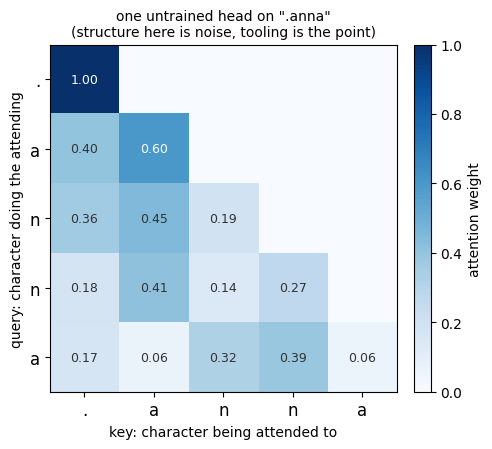

In [14]:
att_mat = att[0].detach().numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(att_mat, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('key: character being attended to', fontsize=10)
ax.set_ylabel('query: character doing the attending', fontsize=10)
ax.set_title('one untrained head on ".anna"\n(structure here is noise, tooling is the point)', fontsize=10)

# write the weight into every non-masked cell so it reads without a mental colour-to-number step
for r in range(len(labels)):
    for c in range(len(labels)):
        if att_mat[r, c] > 0:
            ax.text(c, r, f'{att_mat[r, c]:.2f}', ha='center', va='center',
                    color='white' if att_mat[r, c] > 0.5 else '#333', fontsize=9)

fig.colorbar(im, ax=ax, label='attention weight', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Section 5: why one head is not enough, specifically for names

A single head produces exactly one attention distribution per position. Softmax forces each query's weights to sum to 1, so a head has one unit of attention to spend and it has to spend it all in one place. That is a real bottleneck, and it is easiest to see on a concrete name.

Take the query at the second `n` in `.anna`, deciding what comes next. Two different pieces of the past are useful at the same time. It helps to know what the name *started* with, which lives back at position 0. It also helps to know the *immediately preceding* character, which lives one step back. A single head cannot do both cleanly: to put heavy weight on position 0 it has to take weight away from the previous character, and vice versa. It ends up splitting its one unit of attention and doing each job at half strength.

Multiple heads remove the bottleneck by giving every position several independent attention distributions at once. Each head has its own query, key, and value projections, so each can specialise in a different look-back pattern, and the outputs are concatenated so the position gets to use all of them together. The names dataset genuinely needs this, because several unrelated cues predict the next letter simultaneously.

### Three heads I expect names to want, and what each looks like on the heatmap

I am making these predictions now, before training, and Section 13 checks them against the real trained model. Stating them concretely is the point: a vague "heads learn features" claim cannot be falsified, but "there will be a head with a bright first column" can.

**A start-token anchor.** Names are short and their statistics depend heavily on distance from the beginning: first letters are distributed very differently from interior letters, and the opening of a name constrains the rest. I expect one head whose job is to keep every position oriented to the start. On the heatmap that is a **bright leftmost column**: every query row, whatever character it sits on, dumps most of its weight onto column 0, the `.` token.

**A previous-character head.** A large part of what predicts the next letter is simply the current letter, the same signal the bigram model in Part 2 lived on. I expect a head that re-implements that inside the transformer by attending one step back. On the heatmap that is a **bright band just below the diagonal**: each query attends mostly to the single character immediately before it.

**A last-vowel head.** Names have strong consonant and vowel structure, and to keep a name pronounceable a consonant often needs to know the most recent vowel, not just the previous character. I expect a head that, from a consonant, reaches back to the nearest earlier vowel. On the heatmap that is **bright cells sitting on the vowel columns** (`a`, `e`, `i`, `o`, `u`): a query on a consonant lights up the column of the last vowel it saw.

None of these is something WaveNet could target. WaveNet fuses fixed adjacent pairs, so "always look at the start" or "always look at the last vowel wherever it is" are not patterns it can even represent. Attention can, because the look-back is chosen from content, per position, per name.

In [15]:
class MultiHeadAttention(nn.Module):
    # n_head causal heads in parallel, their outputs concatenated and projected back into the stream.
    # return_attn=True also returns the per-head attention as (B, n_head, T, T), which Section 13 reads.
    def __init__(self, n_embd, n_head, block_size, dropout=0.0):
        super().__init__()
        assert n_embd % n_head == 0, 'n_embd must divide evenly into n_head heads'
        head_size = n_embd // n_head                       # so the concat comes back to exactly n_embd
        self.heads = nn.ModuleList(
            [Head(n_embd, head_size, block_size, dropout) for _ in range(n_head)]
        )
        self.proj = nn.Linear(n_embd, n_embd)              # mix the heads together, project into the stream
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        if return_attn:
            outs, atts = [], []
            for h in self.heads:
                o, a = h(x, return_attn=True)
                outs.append(o)
                atts.append(a)                             # each a is (B, T, T)
            out = torch.cat(outs, dim=-1)                  # (B, T, n_head*head_size) = (B, T, n_embd)
            out = self.resid_drop(self.proj(out))
            return out, torch.stack(atts, dim=1)           # attn stacked as (B, n_head, T, T)

        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.resid_drop(self.proj(out))
        return out

print(MultiHeadAttention(n_embd=64, n_head=4, block_size=block_size))

MultiHeadAttention(
  (heads): ModuleList(
    (0-3): 4 x Head(
      (key): Linear(in_features=64, out_features=16, bias=False)
      (query): Linear(in_features=64, out_features=16, bias=False)
      (value): Linear(in_features=64, out_features=16, bias=False)
      (attn_drop): Dropout(p=0.0, inplace=False)
    )
  )
  (proj): Linear(in_features=64, out_features=64, bias=True)
  (resid_drop): Dropout(p=0.0, inplace=False)
)


### The concatenation and the projection

Each of the four heads returns a `head_size = 16`-dim vector per position. Concatenating them gives back a `4 * 16 = 64`-dim vector, exactly `n_embd`, which is deliberate: the block has to hand the same width back that it received so it can slot into the residual stream in Section 7. But a raw concatenation just stacks four independent opinions side by side with no interaction. The output projection `self.proj` is a learned `Linear(n_embd, n_embd)` that mixes them, letting the model combine "what the start token said" with "what the previous character said" into a single blended representation before passing it on.

The `return_attn` path stacks the four heads' matrices into `(B, n_head, T, T)`. That is the exact tensor Section 13 slices to draw one labelled heatmap per head, so I can lay the trained heads side by side and check the three predictions above.

In [16]:
# confirm the per-head plumbing on '.anna' (still untrained, so the numbers are noise; shapes are the point)
torch.manual_seed(1337)
mha = MultiHeadAttention(n_embd=n_embd, n_head=4, block_size=block_size)
out, att = mha(h, return_attn=True)                 # h is the (1, T, n_embd) embedding of '.anna' from Section 4
print('input  :', tuple(h.shape))
print('output :', tuple(out.shape), ' (same width as input, ready for a residual add)')
print('attn   :', tuple(att.shape), ' (B, n_head, T, T): one T-by-T matrix per head)')
print('each head causal & normalised:', torch.allclose(att.sum(dim=-1), torch.ones(1, 4, att.shape[-1])))

input  : (1, 5, 64)
output : (1, 5, 64)  (same width as input, ready for a residual add)
attn   : (1, 4, 5, 5)  (B, n_head, T, T): one T-by-T matrix per head)
each head causal & normalised: True


## Section 6: feedforward, where each token thinks about what it heard

Attention is communication, but look closely at what it actually computes: a weighted average of values, then a linear projection. That is almost entirely linear. If I stacked attention on attention with nothing in between, the model could keep moving information around but could barely transform it, and depth would buy almost nothing. Each position needs a step that actually processes the vector it just gathered, on its own, with a non-linearity. That step is the feedforward, and the division of labour is clean: attention mixes across positions, the feedforward touches each position independently and never looks sideways. Communicate, then compute.

This is the most direct callback in the notebook to Part 3. The feedforward is exactly the MLP structure from that notebook, Linear then non-linearity then Linear, with one change in granularity. In Part 3 the MLP ran once over a whole flattened three-character window. Here it runs on each position's vector separately, because attention has already pulled the relevant context into that vector, so there is nothing left to flatten. Same building block, applied per position instead of per name.

The one design number is the 4x expansion. The hidden layer is where the non-linearity lives, and a Linear-ReLU-Linear with hidden width `H` can bend its input into on the order of `H` piecewise-linear regions. At `H = n_embd` the per-position function is cramped; widening to `4 * n_embd` gives the ReLU four times as many pieces to work with before projecting back down into the stream. Four is the standard ratio from Vaswani et al. 2017, wide enough to be expressive and narrow enough to stay cheap.

In [17]:
class FeedForward(nn.Module):
    # per-position MLP: expand to 4x width, non-linearity, project back down to n_embd
    def __init__(self, n_embd, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),   # expand: room for the ReLU to implement position-wise functions
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),   # project back so it fits the residual stream
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)                   # acts on each position independently, no mixing across T

ff = FeedForward(n_embd=n_embd)
print(ff)
print('\nshape preserved:', tuple(h.shape), '->', tuple(ff(h).shape))   # h is the '.anna' embedding

FeedForward(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): Dropout(p=0.0, inplace=False)
  )
)

shape preserved: (1, 5, 64) -> (1, 5, 64)


## Section 7: residual connections, the same problem Part 4 fought, solved a different way

Once I start stacking blocks, I run straight back into the problem Part 4 was entirely about. A plain stack computes `x_{l+1} = f_l(x_l)`. To update an early layer, backprop needs `dL/dx_0`, and by the chain rule that is the gradient at the top times the product of every layer's Jacobian:

```
dL/dx_0  =  dL/dx_L · J_{L-1} · J_{L-2} · ... · J_0
```

A product of many matrices. If their singular values sit below 1, the product shrinks toward zero as depth grows, the gradient vanishes, and the earliest layers stop learning. If they sit above 1, it explodes. Either way the signal reaching layer 0 is unreliable. That is the vanishing and exploding gradient problem, and it is the exact failure mode Part 4 taught me to watch for with activation histograms and the gradient-to-data ratio.

Part 4 fixed it by attacking the *size of each factor*. BatchNorm renormalises activations to zero mean and unit variance at every layer, which keeps each Jacobian's singular values near 1 so their product does not drift as fast. Residuals fix the same root cause a different way, by changing the architecture so the chain is not a bare product at all. A residual layer computes

```
x_{l+1} = x_l + f_l(x_l)
```

so its Jacobian is `I + J_l`, the identity plus the sublayer's Jacobian. The backprop chain becomes a product of `(I + J_l)` terms, and if you expand that product, one of the resulting terms is `I · I · ... · I = I`: a path that runs straight from the loss to layer 0 with gradient exactly 1, no matter what any sublayer does to its own `J_l`. Even if every `f_l` contributes almost nothing, that identity highway still delivers the top-level gradient to the earliest layer at full strength. Two different answers to the same question, and modern transformers use both at once, which is why the next section adds LayerNorm on top of these residuals.

In [18]:
# measure the vanishing directly: same layers, same input, residual on vs off
torch.manual_seed(1337)
depth, dim = 40, 64
Ws = [torch.randn(dim, dim) * 0.08 for _ in range(depth)]  # fixed contractive layers, identical for both runs
x0 = torch.randn(1, dim)

def input_grad_norm(use_residual):
    x = x0.clone().requires_grad_(True)
    h = x
    for W in Ws:
        f = torch.tanh(h @ W)              # the sublayer
        h = h + f if use_residual else f   # the only difference is this one '+'
    h.sum().backward()                     # a scalar "loss" so we can read dL/dx0
    return x.grad.norm().item()

print(f'gradient norm reaching the input, 40 layers')
print(f'  without residuals: {input_grad_norm(False):.2e}   <- vanished')
print(f'  with residuals:    {input_grad_norm(True):.2e}   <- survives')

gradient norm reaching the input, 40 layers
  without residuals: 8.50e-08   <- vanished
  with residuals:    8.46e+01   <- survives


The number without residuals is orders of magnitude smaller: after 40 contractive layers the gradient to the input has all but disappeared, so the earliest layer would barely move during training. With the single `+` added, the identity path keeps the gradient at a healthy scale. That is the whole mechanism, and in code it really is one character of difference.

In the block I build in Section 9 the pattern appears twice, wrapping each sublayer so attention and feedforward each get their own highway:

```python
x = x + self.sa(x)      # communicate, but keep a clean path around it
x = x + self.ffwd(x)    # compute, but keep a clean path around it
```

## Section 8: LayerNorm, BatchNorm from Part 4 turned on its side

Residuals keep the gradient alive through depth. LayerNorm keeps the activations well-scaled going in, the other half of what Part 4 was about. And it really is the Part 4 idea, just normalising along a different axis.

In Part 4 I built BatchNorm, which takes one neuron and normalises it across the whole batch: pick a feature, look at its value in every example, make that set zero mean and unit variance. LayerNorm takes one token and normalises across its own features: pick a token, look at all of its numbers, make that set zero mean and unit variance. Same normalisation, perpendicular direction. Laying the batch of token vectors out as a grid, rows are tokens and columns are features, the two norms sweep at right angles:

```
                       features (C)  ->
                     f0    f1    f2    f3
   token 0        [  x     x     x     x  ]  --> LayerNorm: normalise this row
   token 1        [  x     x     x     x  ]  --> LayerNorm: normalise this row
   token 2        [  x     x     x     x  ]  --> LayerNorm: normalise this row
   token 3        [  x     x     x     x  ]  --> LayerNorm: normalise this row
                     |     |     |     |
                     v     v     v     v
                   BatchNorm: normalise each column (one feature over the batch)
```

BatchNorm goes down the columns, tying every token in the batch together through the shared statistics of each feature. LayerNorm goes across the rows, and each token is normalised entirely on its own. Both keep a learnable scale and shift per feature, exactly as in Part 4, so the network can rescale or even undo the normalisation if that is what training wants.

In [19]:
# LayerNorm normalises each token over its own C features (dim=-1), independently of every other token
ln = nn.LayerNorm(n_embd)
normed = ln(h)                          # h is the (1, T, n_embd) embedding of '.anna'

print('per-token mean over features (want ~0):', normed[0].mean(dim=-1).detach().round(decimals=3))
# unbiased=False to match LayerNorm's own variance (divides by N, not N-1); otherwise this reads 1.008 = sqrt(64/63)
print('per-token std  over features (want ~1):', normed[0].std(dim=-1, unbiased=False).detach().round(decimals=3))

per-token mean over features (want ~0): tensor([0., -0., -0., 0., -0.])
per-token std  over features (want ~1): tensor([1., 1., 1., 1., 1.])


Every token comes out zero mean and unit variance over its own features, and crucially none of that depended on the other tokens in the batch. That independence is the reason LayerNorm, not BatchNorm, is the right normaliser for a model that generates one character at a time. BatchNorm's statistics are computed across the batch, so a token's normalised value depends on whatever else happens to be batched with it, and at generation time the batch is a single running name: there is no batch to average over. BatchNorm patches this by keeping running mean and variance from training and switching to them at inference, which is an extra code path, an extra buffer to maintain, and a quiet failure mode if those running stats drift from the generation distribution. That bookkeeping was a real part of Part 4. LayerNorm needs none of it and behaves identically whether it sees one token or ten thousand.

One placement choice remains, and it decides how well the block trains. The original transformer (Vaswani et al. 2017) applied LayerNorm *after* the residual add, `x = LayerNorm(x + sublayer(x))`, which is Post-LN. It works but is delicate to train deep, because the normalisation sits directly on the residual path and keeps rescaling the very signal the Section 7 highway is trying to carry untouched. Modern practice, and what every block here uses, is Pre-LN: normalise the *input* to each sublayer and leave the residual add clean, `x = x + sublayer(LayerNorm(x))`. The residual stream then runs from input to output with nothing rescaling it, the gradient-1 highway stays intact, and each sublayer still receives well-scaled inputs. Pre-LN is what lets these blocks stack and train without warmup tricks, and it is exactly the shape Section 9 assembles.

## Section 9: the Block, one round of communicate then compute

A Block is the unit that stacks. It runs the two things I just built in the Pre-LN arrangement from Section 8: normalise, attend, add back; then normalise, feed-forward, add back. Attention lets the tokens talk, the feedforward lets each token think about what it heard, and the two residual adds keep both wrapped in the gradient highway from Section 7. The diagram traces one Block top to bottom. Notice that the shape is `(B, T, 64)` on every single arrow: a Block transforms the contents of the residual stream without ever changing its shape, which is exactly why Blocks can be stacked to any depth.

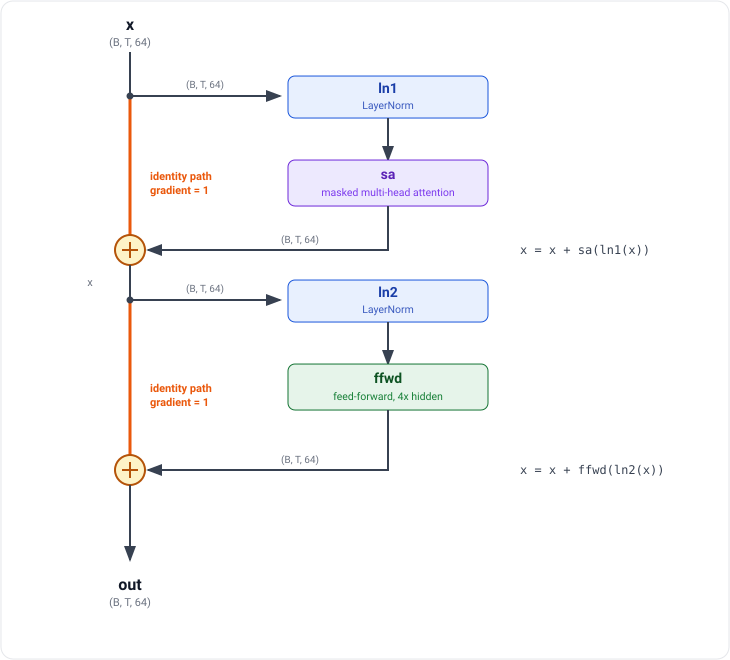

In [20]:
from IPython.display import Image, SVG, display
import os

svg = """<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 730 660" font-family="-apple-system, Segoe UI, Roboto, sans-serif">
  <rect x="1" y="1" width="728" height="658" rx="12" fill="#ffffff" stroke="#e5e7eb"/>
  <defs>
    <marker id="ah" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L8,3 L0,6 Z" fill="#374151"/>
    </marker>
  </defs>
  <text x="130" y="30" text-anchor="middle" font-size="16" font-weight="700" fill="#111827">x</text>
  <text x="130" y="46" text-anchor="middle" font-size="11" fill="#6b7280">(B, T, 64)</text>
  <line x1="130" y1="96" x2="130" y2="250" stroke="#ea580c" stroke-width="3"/>
  <line x1="130" y1="300" x2="130" y2="470" stroke="#ea580c" stroke-width="3"/>
  <text x="150" y="180" font-size="11" fill="#ea580c" font-weight="600">identity path</text>
  <text x="150" y="194" font-size="11" fill="#ea580c" font-weight="600">gradient = 1</text>
  <text x="150" y="392" font-size="11" fill="#ea580c" font-weight="600">identity path</text>
  <text x="150" y="406" font-size="11" fill="#ea580c" font-weight="600">gradient = 1</text>
  <line x1="130" y1="52" x2="130" y2="96" stroke="#374151" stroke-width="2"/>
  <circle cx="130" cy="96" r="3.5" fill="#374151"/>
  <path d="M130,96 H280" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#ah)"/>
  <text x="205" y="88" text-anchor="middle" font-size="10" fill="#6b7280">(B, T, 64)</text>
  <rect x="288" y="76" width="200" height="42" rx="7" fill="#e8f0fe" stroke="#1a56db"/>
  <text x="388" y="93" text-anchor="middle" font-size="14" font-weight="700" fill="#1a3ea8">ln1</text>
  <text x="388" y="109" text-anchor="middle" font-size="10.5" fill="#3b5bbf">LayerNorm</text>
  <path d="M388,118 V160" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="288" y="160" width="200" height="46" rx="7" fill="#ede9fe" stroke="#6d28d9"/>
  <text x="388" y="179" text-anchor="middle" font-size="14" font-weight="700" fill="#5b21b6">sa</text>
  <text x="388" y="196" text-anchor="middle" font-size="10.5" fill="#7c3aed">masked multi-head attention</text>
  <path d="M388,206 V250 H148" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#ah)"/>
  <text x="300" y="243" text-anchor="middle" font-size="10" fill="#6b7280">(B, T, 64)</text>
  <circle cx="130" cy="250" r="15" fill="#fef3c7" stroke="#b45309" stroke-width="2"/>
  <line x1="130" y1="242" x2="130" y2="258" stroke="#b45309" stroke-width="2"/>
  <line x1="122" y1="250" x2="138" y2="250" stroke="#b45309" stroke-width="2"/>
  <line x1="130" y1="265" x2="130" y2="300" stroke="#374151" stroke-width="2"/>
  <text x="90" y="286" text-anchor="middle" font-size="11" fill="#6b7280">x</text>
  <circle cx="130" cy="300" r="3.5" fill="#374151"/>
  <path d="M130,300 H280" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#ah)"/>
  <text x="205" y="292" text-anchor="middle" font-size="10" fill="#6b7280">(B, T, 64)</text>
  <rect x="288" y="280" width="200" height="42" rx="7" fill="#e8f0fe" stroke="#1a56db"/>
  <text x="388" y="297" text-anchor="middle" font-size="14" font-weight="700" fill="#1a3ea8">ln2</text>
  <text x="388" y="313" text-anchor="middle" font-size="10.5" fill="#3b5bbf">LayerNorm</text>
  <path d="M388,322 V364" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="288" y="364" width="200" height="46" rx="7" fill="#e6f4ea" stroke="#137333"/>
  <text x="388" y="383" text-anchor="middle" font-size="14" font-weight="700" fill="#0d5222">ffwd</text>
  <text x="388" y="400" text-anchor="middle" font-size="10.5" fill="#188038">feed-forward, 4x hidden</text>
  <path d="M388,410 V470 H148" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#ah)"/>
  <text x="300" y="463" text-anchor="middle" font-size="10" fill="#6b7280">(B, T, 64)</text>
  <circle cx="130" cy="470" r="15" fill="#fef3c7" stroke="#b45309" stroke-width="2"/>
  <line x1="130" y1="462" x2="130" y2="478" stroke="#b45309" stroke-width="2"/>
  <line x1="122" y1="470" x2="138" y2="470" stroke="#b45309" stroke-width="2"/>
  <path d="M130,485 V560" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#ah)"/>
  <text x="130" y="590" text-anchor="middle" font-size="16" font-weight="700" fill="#111827">out</text>
  <text x="130" y="606" text-anchor="middle" font-size="11" fill="#6b7280">(B, T, 64)</text>
  <text x="520" y="254" font-size="12" font-family="monospace" fill="#374151">x = x + sa(ln1(x))</text>
  <text x="520" y="474" font-size="12" font-family="monospace" fill="#374151">x = x + ffwd(ln2(x))</text>
</svg>"""

os.makedirs('outputs/plots', exist_ok=True)
with open('outputs/plots/09_block_diagram.svg', 'w') as f:
    f.write(svg)

# GitHub does not reliably render SVG cell outputs, so embed a PNG for viewing and keep the vector source alongside it
try:
    import cairosvg
    cairosvg.svg2png(bytestring=svg.encode(), write_to='outputs/plots/09_block_diagram.png', output_width=730)
    display(Image('outputs/plots/09_block_diagram.png'))
except Exception:
    display(SVG(svg))

In [21]:
class Block(nn.Module):
    # one transformer block: Pre-LN attention + residual, then Pre-LN feedforward + residual
    def __init__(self, n_embd, n_head, block_size, dropout=0.0):
        super().__init__()
        self.ln1  = nn.LayerNorm(n_embd)
        self.sa   = MultiHeadAttention(n_embd, n_head, block_size, dropout)
        self.ln2  = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward(n_embd, dropout)

    def forward(self, x, return_attn=False):
        if not return_attn:                          # training and generation: the block is these two lines
            x = x + self.sa(self.ln1(x))
            x = x + self.ffwd(self.ln2(x))
            return x
        attended, att = self.sa(self.ln1(x), return_attn=True)   # inspection only (Section 13), same maths
        x = x + attended
        x = x + self.ffwd(self.ln2(x))
        return x, att

print(Block(n_embd=64, n_head=4, block_size=block_size))

Block(
  (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (sa): MultiHeadAttention(
    (heads): ModuleList(
      (0-3): 4 x Head(
        (key): Linear(in_features=64, out_features=16, bias=False)
        (query): Linear(in_features=64, out_features=16, bias=False)
        (value): Linear(in_features=64, out_features=16, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
      )
    )
    (proj): Linear(in_features=64, out_features=64, bias=True)
    (resid_drop): Dropout(p=0.0, inplace=False)
  )
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (ffwd): FeedForward(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=64, bias=True)
      (3): Dropout(p=0.0, inplace=False)
    )
  )
)


The forward pass is the whole payoff of the last three sections. Read the two training lines against the diagram: each sublayer is called on the LayerNormed input and its result is *added* to `x` rather than replacing it. Those two `+` are the two orange highways in the picture. Section 7 showed that an additive path carries the gradient back with factor 1, so stacking many Blocks does not choke the gradient to the early layers, and Section 8's Pre-LN placement keeps those highways clean by normalising only the inputs to the sublayers, never the stream itself. Attention and feedforward sit off to the side as optional detours that the residual stream can lean on as much or as little as training decides. That is what makes a Block safe to repeat, which is the next section.

## Section 10: assembling the NameTransformer

Every piece now exists. The full model is a thin wrapper that turns character ids into next-character logits in four steps, three of which already have their own sections above:

1. **Token embedding**, a lookup table mapping each of the 27 characters to a learned `n_embd` vector. This is the direct descendant of the table `C` from Part 3.
2. **Position embedding**, the one component I have not yet justified. Attention, as I built it in Section 3, is order-blind: drop the causal mask and the operation treats the past as an unordered set, with no built-in notion that position 3 comes after position 2. The Part 3 MLP got order for free from where each character landed in the flattened window, and WaveNet got it from the fixed shape of the tree. Attention has neither, so I add order back explicitly: a second table mapping each position `0..block_size-1` to its own learned vector, summed into the token embedding. The vector entering the first block then carries both what the character is and where it sits.
3. **The stack of blocks**, `n_layer` Blocks from Section 9, each one round of communicate then compute.
4. **Final LayerNorm and linear head**, a last normalisation, then a `Linear` projecting each position's vector to 27 logits, one score per possible next character.

### Hyperparameters, and why they differ from the Shakespeare model

Every value that differs from my Shakespeare GPT is smaller, for the same underlying reason: names.txt is a smaller, simpler dataset than a megabyte of Shakespeare.

| Hyperparameter | Names (here) | Shakespeare | Why it differs |
|---|---|---|---|
| `block_size` | 16 | 256 | The longest name is 15 characters. Shakespeare needed 256 to hold sentence context; paying for context a name never uses would only waste compute. |
| `n_embd` | 64 | 384 | A 27-character vocabulary with simple phonetic structure needs far less width than 65 characters of semantically rich English. |
| `n_head` | 4 | 6 | At `n_embd` 64, four heads keep `head_size` at a usable 16. More heads would slice each too thin to learn a distinct pattern. |
| `n_layer` | 6 | 6 | The one number I kept. Names are short, but several rounds of communicate then compute still help, and depth is cheap at this width. |
| `dropout` | 0.2 | 0.2 | Unchanged. The model is over-parameterised for this data, so regularisation does real work. |
| `learning_rate` | 1e-3 | 3e-4 | A smaller model tolerates larger steps, and 1e-3 is the makemore default carried from Parts 3 to 5. |

The honest tradeoff is in the parameter count. This model has about 303k parameters, but the training split holds only about 180k next-character predictions. It is over-parameterised: it has enough capacity to memorise the training names outright. That is not a mistake, it is the regime every model in this series has lived in on names.txt, and it is exactly why dropout and a held-out val split matter. It also means val loss will be bounded more by the intrinsic difficulty of the dataset than by the architecture. I expect this model to fit the training set better than anything before it, and I am not expecting a miracle on val. Section 12 reports both, honestly.

### Where the capacity lives

The parameter breakdown printed below makes one thing vivid: just under 99% of the weights sit in the six blocks, and the two embedding tables together are under 1%. Every bit of the model's ability to actually transform representations is in the attention and feedforward layers, which is where the real work happens. The embeddings are only the entry and exit ramps.

In [22]:
# model hyperparameters (justified in the table above)
n_embd  = 64
n_head  = 4
n_layer = 6
dropout = 0.2

In [23]:
class NameTransformer(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout=0.0):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, n_embd)     # what each character is
        self.pos_emb   = nn.Embedding(block_size, n_embd)     # where each character sits
        self.blocks = nn.ModuleList(
            [Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)                      # final norm before the head
        self.head = nn.Linear(n_embd, vocab_size)            # -> one logit per possible next character

    def forward(self, idx, targets=None, return_attn=False):
        B, T = idx.shape
        x = self.token_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))   # (B, T, n_embd)
        attn_maps = []
        for block in self.blocks:
            if return_attn:
                x, a = block(x, return_attn=True)
                attn_maps.append(a)                          # collect (B, n_head, T, T) per layer for Section 13
            else:
                x = block(x)
        logits = self.head(self.ln_f(x))                     # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # ignore_index=-1 skips the padded targets from Section 2, keeping the loss comparable to Parts 3-5
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        if return_attn:
            return logits, loss, attn_maps
        return logits, loss

In [24]:
torch.manual_seed(1337)
model = NameTransformer(vocab_size, n_embd, n_head, n_layer, block_size, dropout)

def param_count(module):
    return sum(p.numel() for p in module.parameters())

emb   = param_count(model.token_emb) + param_count(model.pos_emb)
blk   = param_count(model.blocks)
final = param_count(model.ln_f) + param_count(model.head)
total = param_count(model)

print(f'{"embeddings (token + position)":<32}{emb:>8,}   {100*emb/total:4.1f}%')
print(f'{"6 blocks":<32}{blk:>8,}   {100*blk/total:4.1f}%')
print(f'{"    per block":<32}{blk//n_layer:>8,}')
print(f'{"final LayerNorm + head":<32}{final:>8,}   {100*final/total:4.1f}%')
print('-' * 46)
print(f'{"total":<32}{total:>8,}')

embeddings (token + position)      2,752    0.9%
6 blocks                         298,752   98.5%
    per block                     49,792
final LayerNorm + head             1,883    0.6%
----------------------------------------------
total                            303,387


## Section 11: training, and watching it learn

The training loop is the same shape I have used since Part 3: sample a batch, forward, backward, step, repeat. Three things are worth calling out.

First, device selection follows the cascade from my Shakespeare script: CUDA if there is an NVIDIA GPU, then Apple's MPS backend (which is how I trained the Shakespeare models on an M3 Air, no separate GPU needed), then CPU. The names model is small enough that CPU is fine.

Second, I track loss two ways. During training `estimate_loss` averages over a few sampled batches per split, which is cheap and gives the curve. At the end I compute the exact loss over the *full* train, dev, and test splits with `ignore_index=-1`, which is the number that is directly comparable to the bigram, MLP, and WaveNet results, since those were scored the same way on the same split.

Third, and this is the diagnostic I carried over from my Shakespeare training analysis, I log the update ratio `log10(lr * grad.std / param.std)` for every parameter, grouped into embeddings, attention (query, key, value, proj), feedforward, and LayerNorm. The rule of thumb is that this should sit around -3: much lower and the weights are barely moving, much higher and training is unstable. I plot it next to the loss curve with the -3 line marked, exactly as I did for Shakespeare.

In [25]:
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')

batch_size    = 64
max_iters     = 5000
eval_interval = 250
eval_iters    = 100
learning_rate = 1e-3

model = model.to(device)
print('training on', device)

training on mps


In [26]:
def get_batch(split):
    X, Y = (Xtr, Ytr) if split == 'train' else (Xdev, Ydev)
    ix = torch.randint(len(X), (batch_size,))
    return X[ix].to(device), Y[ix].to(device)

@torch.no_grad()
def estimate_loss():                       # cheap sampled estimate, for the training curve
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

@torch.no_grad()
def full_loss(X, Y, chunk=2048):           # exact loss over a whole split, the comparable number
    model.eval()
    total, count = 0.0, 0
    for i in range(0, len(X), chunk):
        xb, yb = X[i:i+chunk].to(device), Y[i:i+chunk].to(device)
        logits, _ = model(xb)
        l = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1), ignore_index=-1, reduction='sum')
        total += l.item()
        count += (yb != -1).sum().item()
    model.train()
    return total / count

def param_group(name):                     # bucket each parameter for the update-ratio plot
    if any(k in name for k in ['key', 'query', 'value', 'proj']): return 'attention'
    if 'ffwd' in name:                                            return 'feedforward'
    if '.ln' in name or name.startswith('ln'):                   return 'layernorm'
    if 'emb' in name or 'head' in name:                          return 'embeddings'
    return 'other'

In [27]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
torch.manual_seed(1337)   # re-seed so the run is reproducible regardless of the demo cells above

train_hist, val_hist, hist_steps, ud = [], [], [], []

for step in range(max_iters):
    if step % eval_interval == 0 or step == max_iters - 1:
        losses = estimate_loss()
        train_hist.append(losses['train']); val_hist.append(losses['val']); hist_steps.append(step)
        print(f'step {step:4d} | train {losses["train"]:.4f} | val {losses["val"]:.4f}')

    xb, yb = get_batch('train')
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    if step % eval_interval == 0 or step == max_iters - 1:            # log update ratios after backward, before step
        with torch.no_grad():
            ratios = [(n, (learning_rate * p.grad.std() / (p.data.std() + 1e-12)).log10().item())
                      for n, p in model.named_parameters() if p.grad is not None]
        ud.append({'step': step, 'ratios': ratios})

    optimizer.step()

step    0 | train 3.5622 | val 3.5751
step  250 | train 2.2289 | val 2.2190
step  500 | train 2.1565 | val 2.1692
step  750 | train 2.1208 | val 2.1488
step 1000 | train 2.0845 | val 2.1141
step 1250 | train 2.0705 | val 2.0912
step 1500 | train 2.0439 | val 2.0784
step 1750 | train 2.0416 | val 2.0686
step 2000 | train 2.0173 | val 2.0572
step 2250 | train 2.0005 | val 2.0514
step 2500 | train 1.9940 | val 2.0479
step 2750 | train 1.9839 | val 2.0311
step 3000 | train 1.9669 | val 2.0355
step 3250 | train 1.9603 | val 2.0190
step 3500 | train 1.9517 | val 2.0180
step 3750 | train 1.9387 | val 2.0116
step 4000 | train 1.9286 | val 2.0209
step 4250 | train 1.9338 | val 2.0089
step 4500 | train 1.9167 | val 2.0012
step 4750 | train 1.9197 | val 2.0048
step 4999 | train 1.8972 | val 1.9882


In [28]:
# the comparable numbers: exact NLL over the full splits
tr = full_loss(Xtr, Ytr)
vl = full_loss(Xdev, Ydev)
te = full_loss(Xte, Yte)
print(f'full-split NLL    train {tr:.4f} | val {vl:.4f} | test {te:.4f}')
print(f'train/val gap     {vl - tr:.4f}')
print(f'best sampled val  {min(val_hist):.4f} at step {hist_steps[val_hist.index(min(val_hist))]}')

full-split NLL    train 1.9092 | val 1.9991 | test 1.9983
train/val gap     0.0899
best sampled val  1.9882 at step 4999


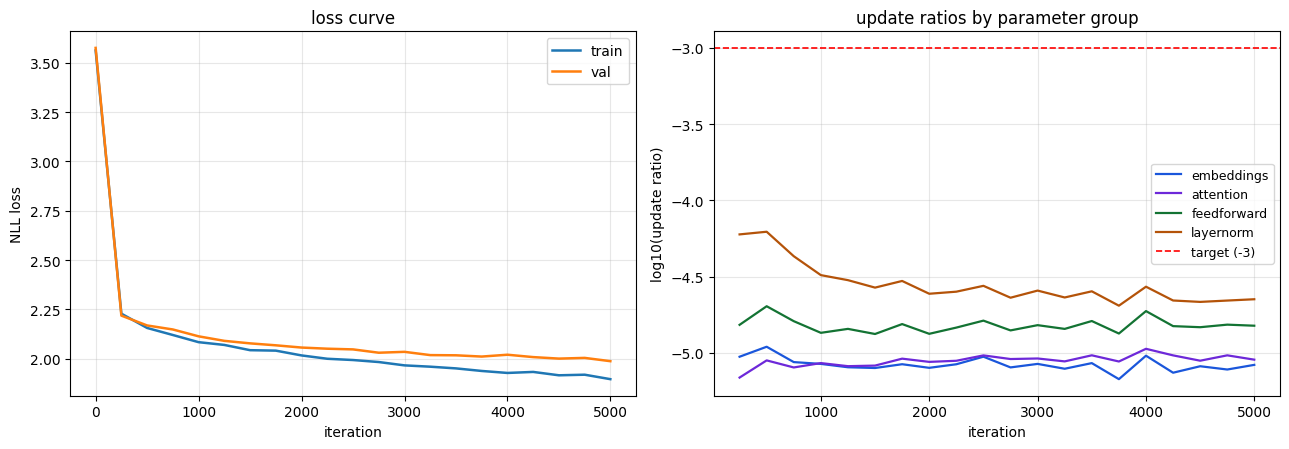

In [29]:
from collections import defaultdict

# average the update ratios within each group, skipping step 0 (LayerNorm inits to constant weights,
# so its param.std is 0 there and the ratio is undefined; every other step is well defined)
ud_plot = [e for e in ud if e['step'] > 0]
ud_steps = [e['step'] for e in ud_plot]
series = defaultdict(list)
for e in ud_plot:
    b = defaultdict(list)
    for name, val in e['ratios']:
        b[param_group(name)].append(val)
    for g in ['embeddings', 'attention', 'feedforward', 'layernorm']:
        series[g].append(sum(b[g]) / len(b[g]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

ax1.plot(hist_steps, train_hist, label='train', linewidth=1.8)
ax1.plot(hist_steps, val_hist,   label='val',   linewidth=1.8)
ax1.set_xlabel('iteration'); ax1.set_ylabel('NLL loss'); ax1.set_title('loss curve')
ax1.legend(); ax1.grid(alpha=0.3)

colors = {'embeddings': '#1a56db', 'attention': '#6d28d9', 'feedforward': '#137333', 'layernorm': '#b45309'}
for g in ['embeddings', 'attention', 'feedforward', 'layernorm']:
    ax2.plot(ud_steps, series[g], label=g, linewidth=1.6, color=colors[g])
ax2.axhline(y=-3, color='red', linestyle='--', linewidth=1.2, label='target (-3)')
ax2.set_xlabel('iteration'); ax2.set_ylabel('log10(update ratio)')
ax2.set_title('update ratios by parameter group'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('outputs/plots', exist_ok=True)
plt.savefig('outputs/plots/11_training.png', dpi=130)
plt.show()

### Reading the two plots

**The loss curve.** Training drops fast, from 3.56 at initialisation to about 2.2 within 250 steps, then grinds down steadily to a full-split **train 1.91, val 2.00, test 2.00**. Two things stand out. The val curve tracks the train curve closely the whole way, ending only 0.09 above it, so despite being over-parameterised the model is *not* overfitting badly, which is dropout earning its place. And val 2.00 is the best number in the series: bigram 2.45, MLP 2.16, BatchNorm 2.10, WaveNet 2.24, transformer 2.00. Section 12 lays that comparison out in full, but the headline is that attention plus a held-out split plus dropout generalises better here than anything before it.

**The update ratios.** All four groups sit tightly together around -4.5 to -5.2, below the -3 rule of thumb, and they stay flat and clustered for the whole run. Two honest readings. First, the absolute level: this is the SGD-style ratio `lr * grad.std / param.std`, but I trained with AdamW, which normalises each parameter's step by its own gradient history, so the true step is larger than this number suggests. The proof is the loss curve itself, a model "stuck at -5" does not fall from 3.56 to 1.91. So I read the level as a known understatement, not as a problem. Second, and this is where the plot earns its place, the four groups move in lockstep with none of them frozen. That is a healthier picture than my Shakespeare 0.82M run, where the embedding layer sat far below the rest at around -7.5. Here the embeddings update right alongside attention and feedforward, which is what I want to see. (Step 0 is dropped from this plot: LayerNorm initialises to constant weights, so its `param.std` is 0 at the very first step and the ratio is undefined there.)

## Section 12: results

### Generating names

Sampling a name is the same autoregressive loop from Part 3, now run through the transformer. I start from the `.` token, forward the model, take the logits at the last position, turn them into probabilities, and sample the next character. I append it and repeat, stopping when the model emits `.` again to close the name.

The one knob I add is **temperature**. Before the softmax I divide the logits by a temperature `T`. `T` below 1 sharpens the distribution, so the model leans harder on its most likely characters and names come out conservative, often real names it saw in training. `T` above 1 flattens the distribution, spreading probability toward unlikely characters, so names come out adventurous and sometimes barely pronounceable. `T = 1` is the model's own distribution, untouched. Below I sample 30 names at each of three temperatures so the effect is visible at a glance.

In [30]:
@torch.no_grad()
def generate_name(temperature=1.0):
    idx = torch.tensor([[0]], device=device)          # start from the '.' token
    out = []
    for _ in range(block_size):                        # a name never exceeds block_size tokens
        logits, _ = model(idx[:, -block_size:])
        logits = logits[:, -1, :] / temperature        # temperature scaling on the last position
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, num_samples=1)
        if nxt.item() == 0:                            # '.' -> end of name
            break
        out.append(nxt.item())
        idx = torch.cat([idx, nxt], dim=1)
    return ''.join(itos[i] for i in out)

In [31]:
import os
model.eval()
torch.manual_seed(42)

temps = [0.8, 1.0, 1.4]
cols = {t: [generate_name(t) for _ in range(30)] for t in temps}

print(f'{"temp 0.8 (safe)":<16}{"temp 1.0 (balanced)":<20}{"temp 1.4 (creative)":<20}')
print('-' * 56)
for i in range(30):
    print(f'{cols[0.8][i]:<16}{cols[1.0][i]:<20}{cols[1.4][i]:<20}')

# save the temperature-1.0 names as the notebook's generated-name artifact
os.makedirs('outputs/generated', exist_ok=True)
with open('outputs/generated/05_transformer_generated.txt', 'w') as f:
    f.write('# Names generated by the character-level Transformer (Section 12)\n')
    f.write('# temperature 1.0 | full-split val NLL 2.00 | 303,387 parameters\n')
    f.write('# ' + '-' * 58 + '\n')
    f.write('\n'.join(cols[1.0]) + '\n')
print('\nsaved 30 temperature-1.0 names to outputs/generated/05_transformer_generated.txt')

temp 0.8 (safe) temp 1.0 (balanced) temp 1.4 (creative) 
--------------------------------------------------------
garnella        dako                jaxylah             
reig            ailani              couhaure            
dasire          aksh                shoylinn            
briner          alijah              ivayane             
alora           kianni              xhoemibe            
archlenn        pertric             hobby               
nohi            kingy               marvy               
alahaya         giorgeagh           jesleight           
elaria          chillyann           mairona             
june            soum                julayah             
aaelynn         jamayah             zum                 
taora           flendle             bremoenn            
jalani          mikyla              empt                
roserley        jasmyn              dokai               
antariel        cambrell            micone              
alex            mian           

The trend is exactly what temperature should produce. At 0.8 the model plays it safe and many outputs are real names or one edit away from one. At 1.4 it invents freely, and the outputs get longer and stranger, some of them past the edge of pronounceable. At 1.0, its own distribution, it sits in between: mostly novel, mostly plausible. The model has clearly learned a distribution over names, not a lookup table.

### The whole series, side by side

Every model in the series, scored the same way on the same 80/10/10 split of the same 32,033 names:

| Model | Context | Parameters | Train NLL | Val NLL |
|---|---|---|---|---|
| Bigram (Part 2) | 1 char | 729 | 2.45 | 2.45 |
| MLP (Part 3) | 3 chars | 11,897 | 2.16 | 2.16 |
| BatchNorm MLP (Part 4) | 3 chars | 47,024 | 2.04 | 2.10 |
| WaveNet (Part 5) | 8 chars | 76,579 | 1.73 | 2.24 |
| **Transformer (this)** | **16 chars** | **303,387** | **1.91** | **2.00** |

### Reading the table honestly

The Transformer takes the best validation loss in the series at 2.00, ahead of the BatchNorm MLP at 2.10. But look at the size of that win: 0.10 nats, bought with roughly six times the parameters and twice the context. That is the honest headline. On 32,000 short names the bottleneck is not the architecture, it is the data. There is only so much to know about what makes a plausible name from 32k examples, and by Part 4 the models were already close to extracting it.

What the Transformer actually does better is generalise, not memorise. WaveNet has the lowest train loss of anything here at 1.73, yet the worst validation of the neural models at 2.24, a 0.51 gap, because it overfit the training names. The Transformer's train and val sit only 0.09 apart. So the real lesson of this table is not "attention wins." It is that attention, together with dropout and a clean residual and normalisation setup, gives the best generalisation, and that on small data the returns to a bigger architecture are real but modest. The place attention pulls decisively ahead is precisely where this dataset cannot show it: long sequences, where its O(1) path between any two positions beats WaveNet's O(log T) tree and the MLP's fixed window. That is the Shakespeare regime, and it is why the same architecture that gains a tenth of a nat here is the one that scales to the entire internet.

## Section 13: reading the attention

This is the section the whole notebook was built for. Because I put `return_attn=True` in the `Head` back in Section 4 and threaded it up through the model, I can now run the trained model on any name and pull out every head's attention matrix, all six layers by four heads. On Shakespeare these would be inscrutable. On names, where the sequences are short and the structure is obvious, I can actually read them.

I run four names chosen for structure: `olivia` (vowel start, vowel-heavy), `anna` (a repeated character), `christopher` (long, with consonant clusters), and `mia` (short). For each I show the full six-by-four grid so nothing is hidden, then zoom in on the heads where the patterns are clearest. In every heatmap the rows are the query (the character doing the looking), the columns are the key (the character being looked at), and the matrix is lower-triangular because of the causal mask. Both axes are labelled with the actual characters.

The purpose is to check, out loud, the three predictions I made in Section 5 before training anything: a start-token anchor (a bright first column), a previous-character head (a bright subdiagonal), and a last-vowel head (bright vowel columns). Two held. One did not, and the way it failed is the most instructive thing in the notebook.

In [32]:
names_to_read = ['olivia', 'anna', 'christopher', 'mia']

@torch.no_grad()
def attention_maps(name):
    model.eval()
    seq = [0] + [stoi[c] for c in name]                     # start token, then the name
    idx = torch.tensor([seq], device=device)
    _, _, maps = model(idx, return_attn=True)               # maps: 6 layers of (1, n_head, T, T)
    return [m[0].cpu().numpy() for m in maps], ['.'] + list(name)

def draw_head(ax, A, labels, title, annotate=True):
    ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=11)
    ax.set_title(title, fontsize=10)
    if annotate:
        for r in range(len(labels)):
            for c in range(len(labels)):
                if A[r, c] > 0.005:
                    ax.text(c, r, f'{A[r, c]:.2f}', ha='center', va='center',
                            color='white' if A[r, c] > 0.5 else '#333', fontsize=8)

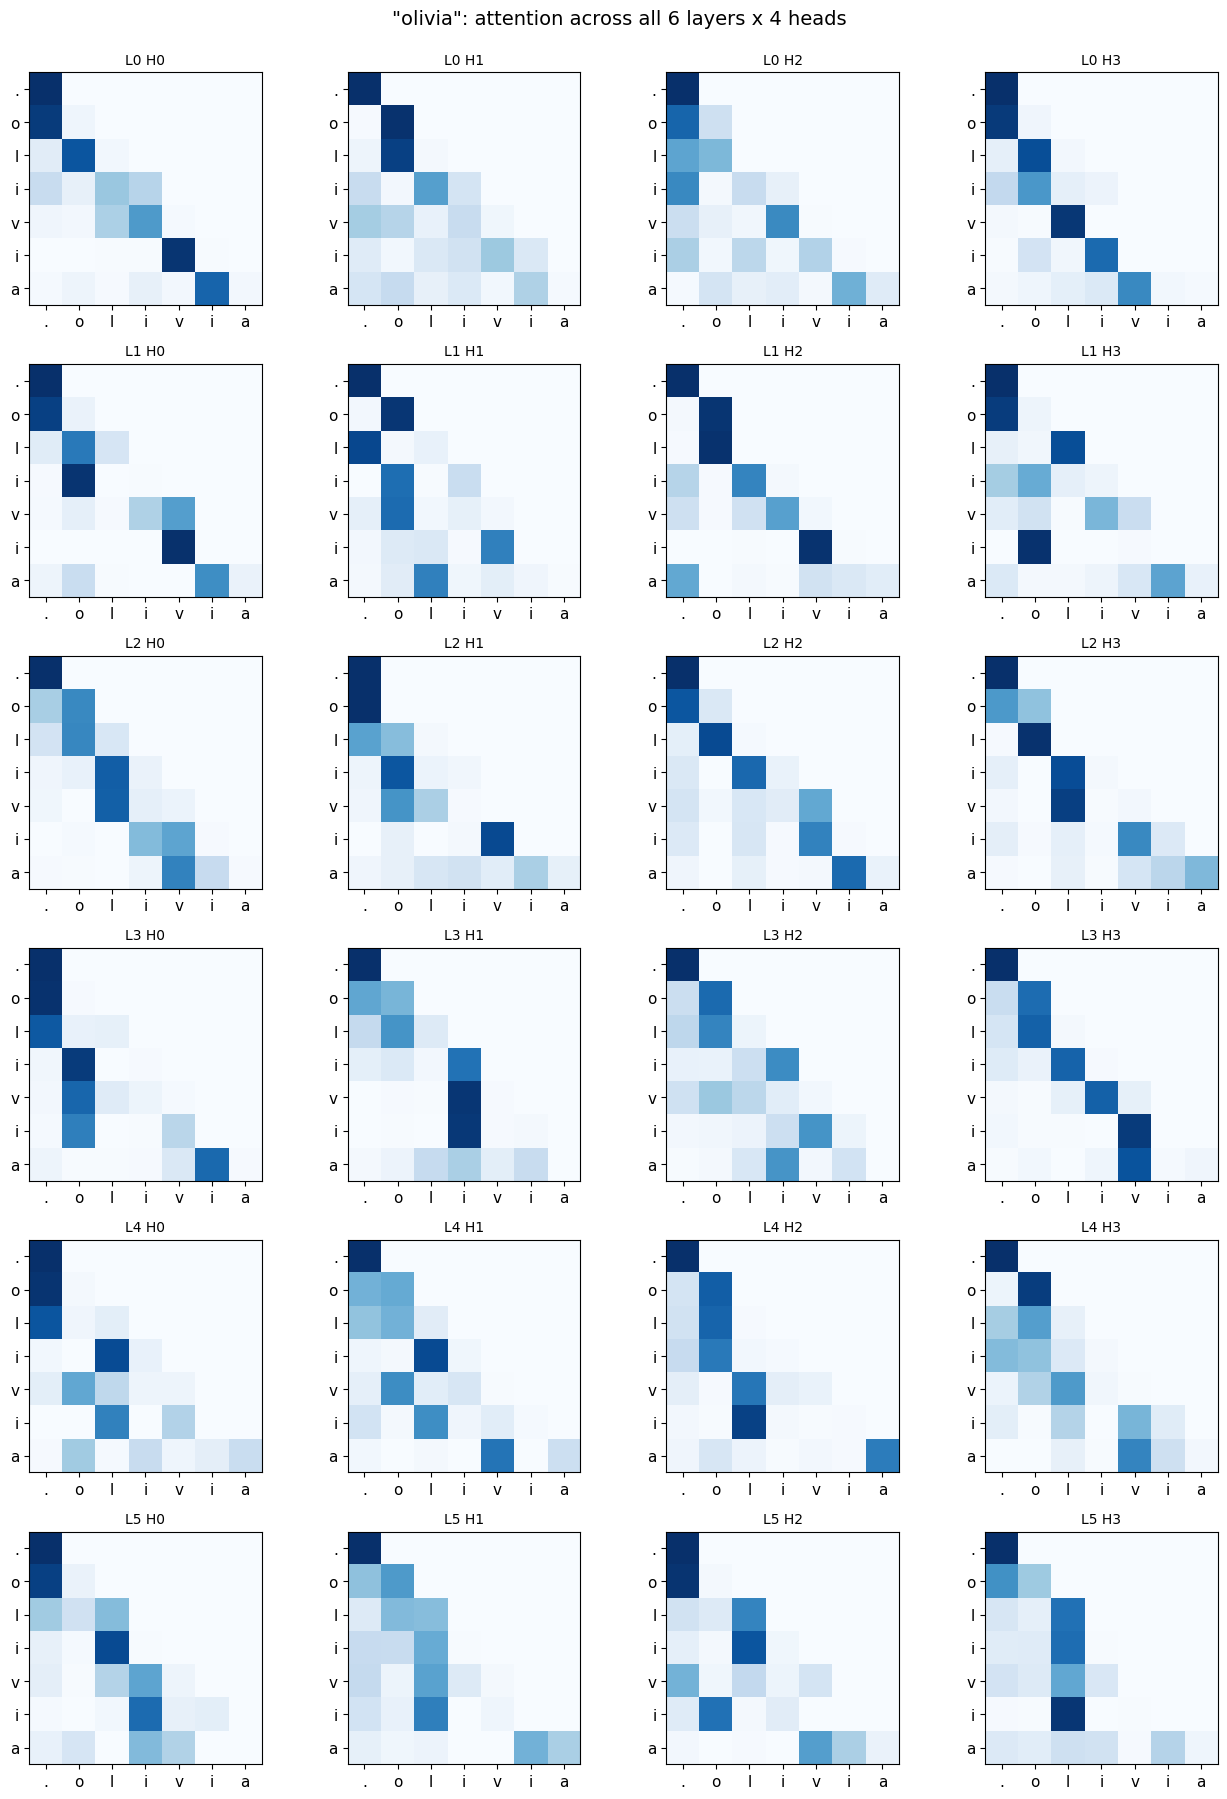

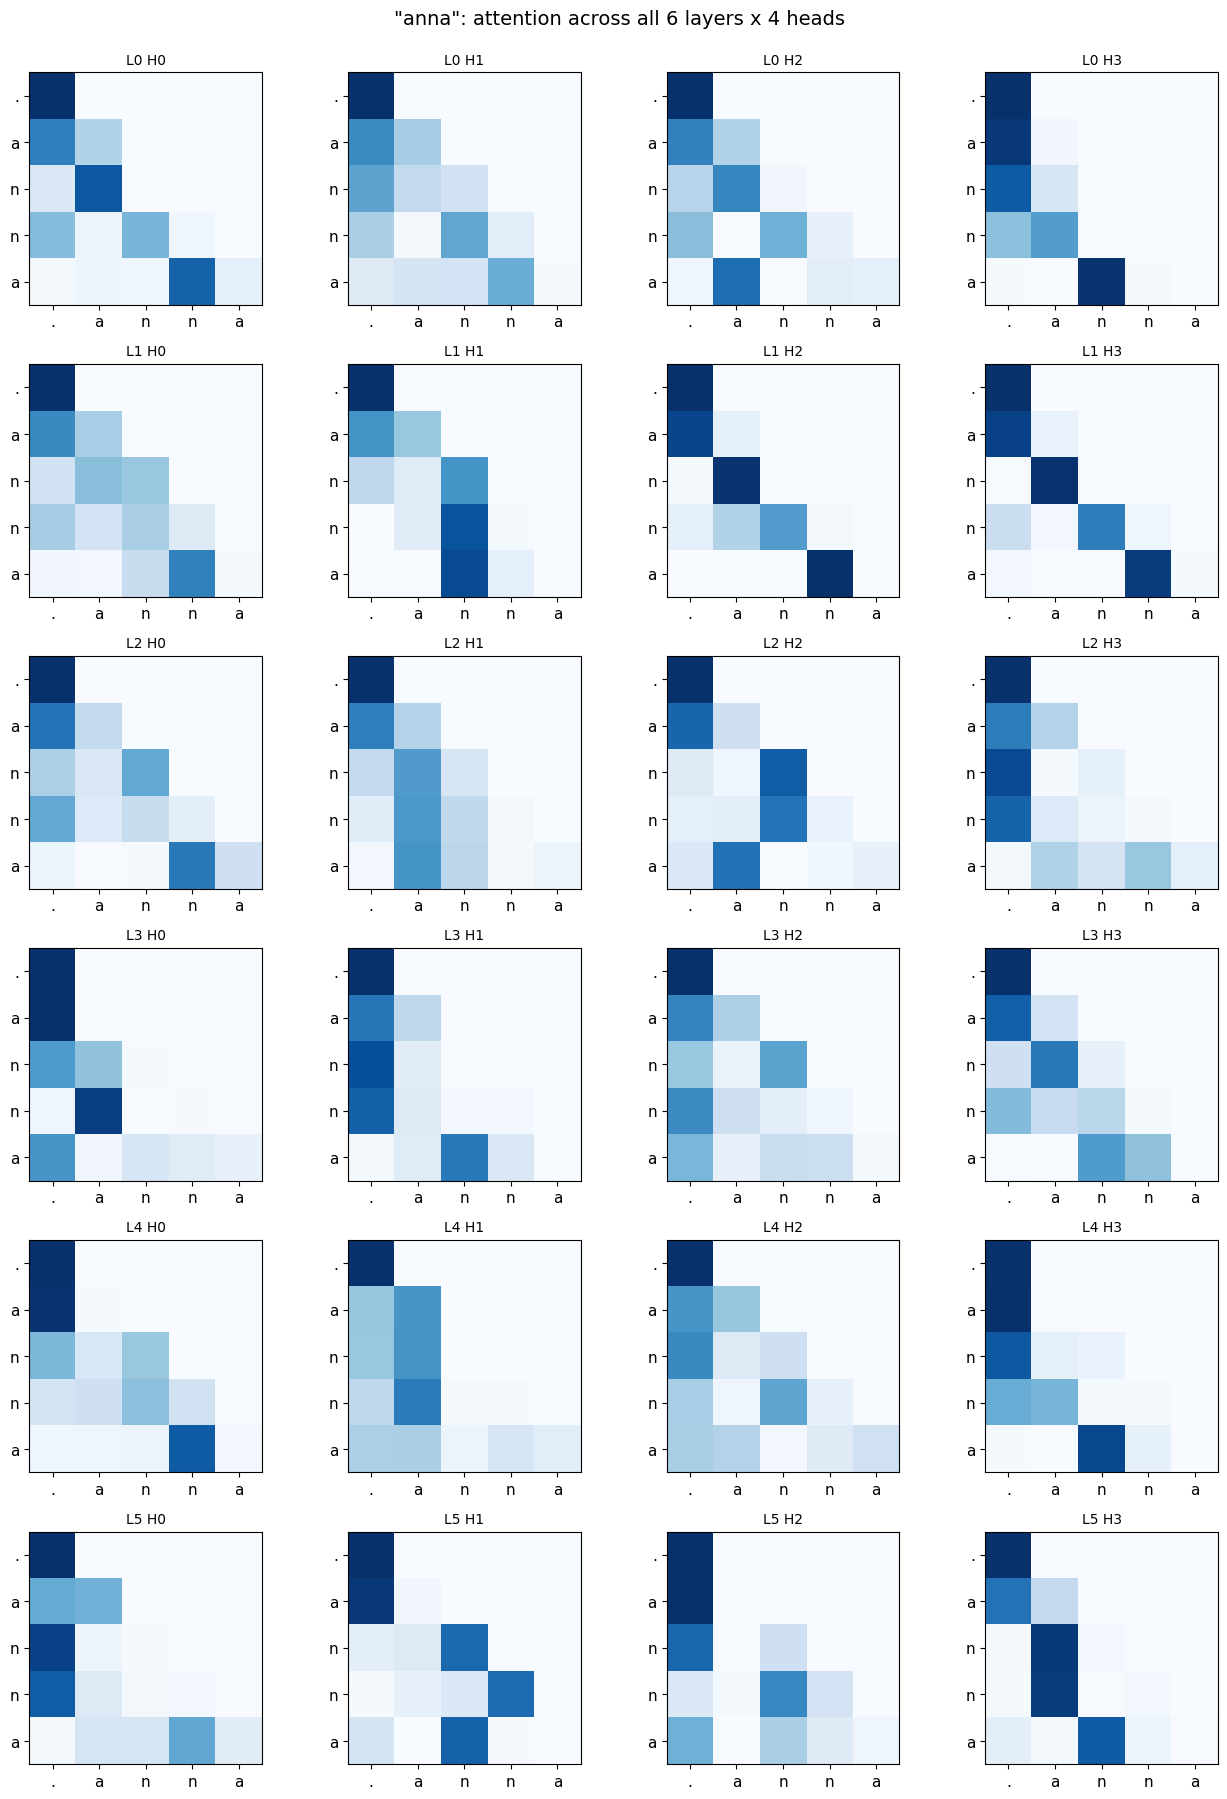

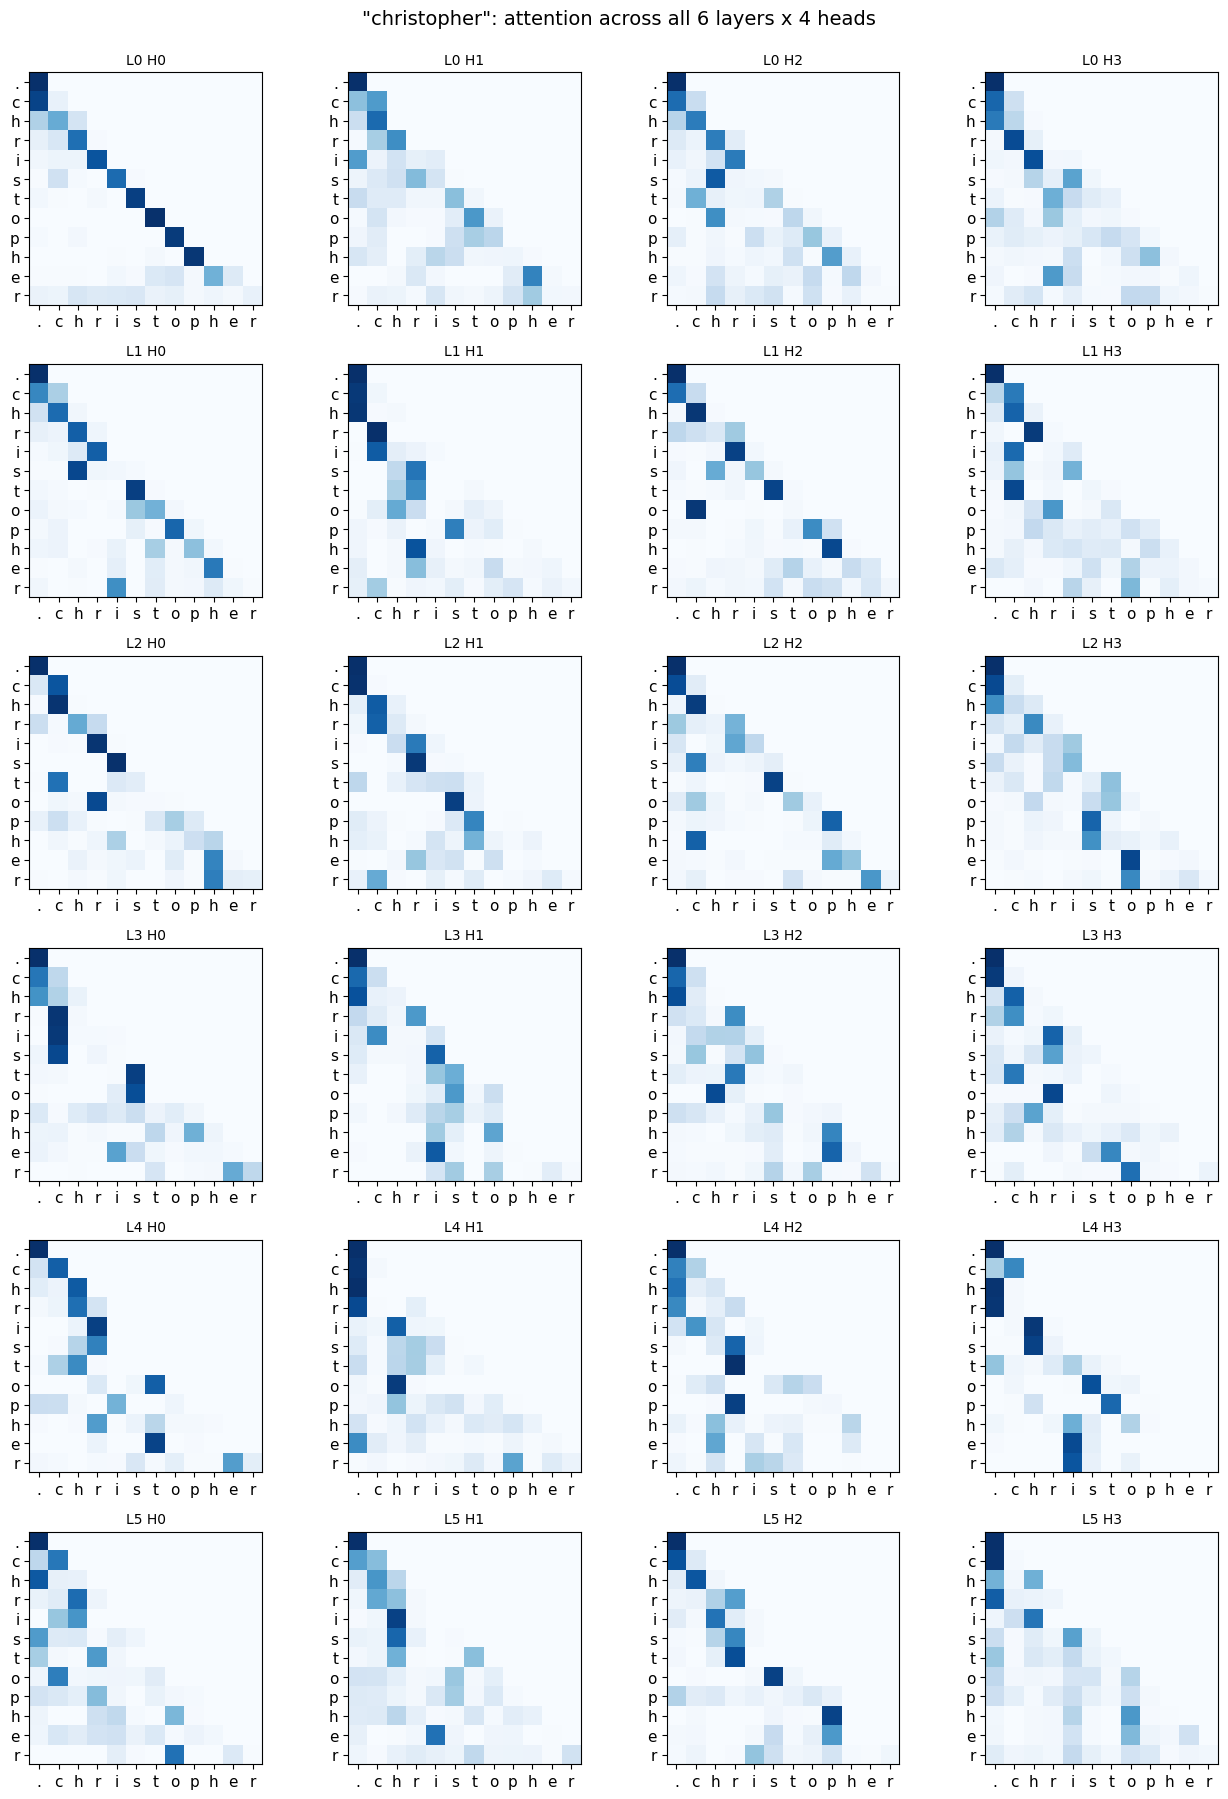

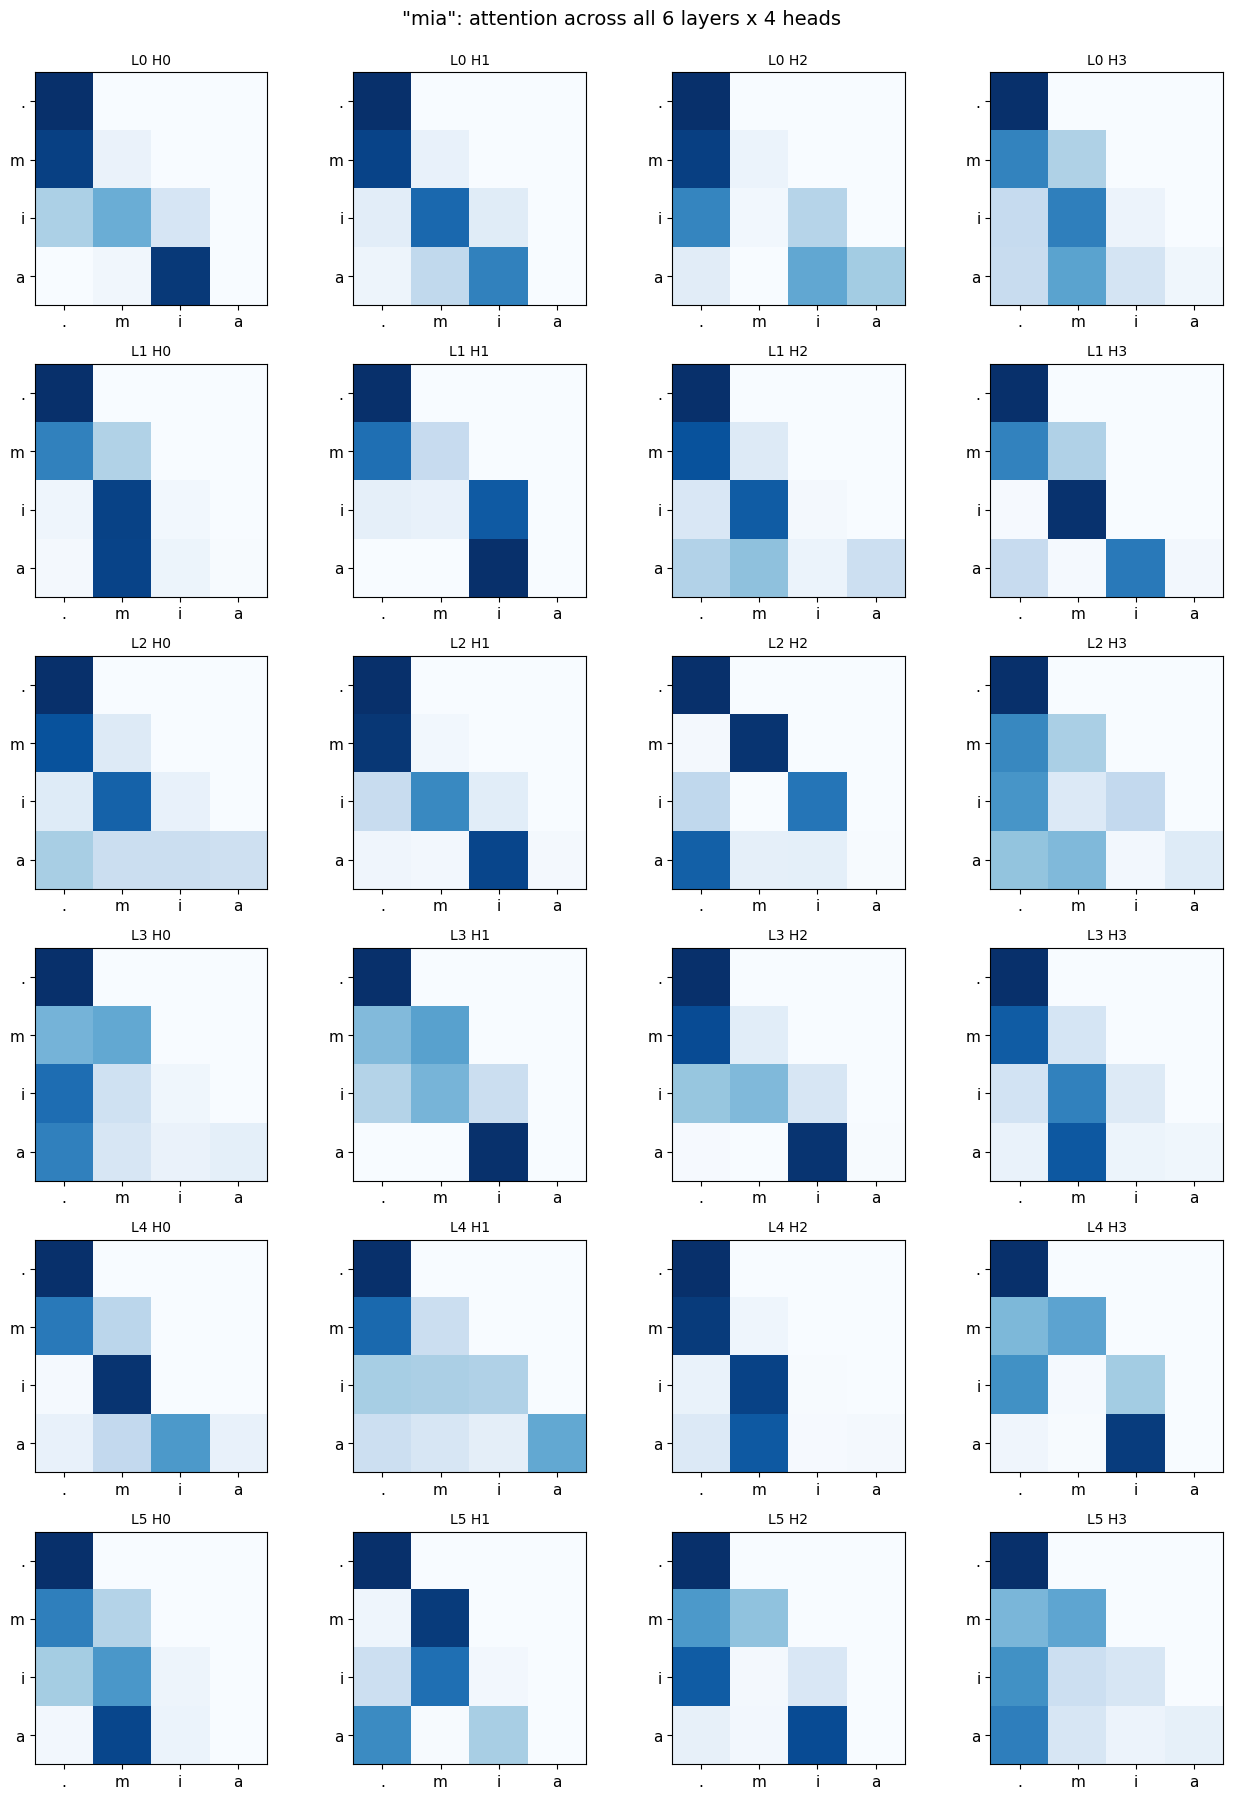

In [33]:
# the complete map: every layer, every head, for each name (color only; the zoom-ins below are annotated)
for name in names_to_read:
    maps, labels = attention_maps(name)
    fig, axes = plt.subplots(6, 4, figsize=(13, 18))
    for L in range(6):
        for H in range(4):
            draw_head(axes[L, H], maps[L][H], labels, f'L{L} H{H}', annotate=False)
    fig.suptitle(f'"{name}": attention across all 6 layers x 4 heads', fontsize=14, y=0.997)
    plt.tight_layout()
    plt.savefig(f'outputs/plots/13_grid_{name}.png', dpi=90)
    plt.show()

### What the grids show before I zoom in

Two things jump out of the grids even at this size. First, the heads are clearly *not* redundant: within any layer the four heads have visibly different shapes, which is the multi-head argument from Section 5 vindicated, each head really did specialise. Second, and I did not predict this, there is a clear organisation by depth. The early layers (0 and 1) are dominated by tight diagonal and subdiagonal bands, local patterns. The deep layers (4 and 5) shift weight into the first column and into scattered vertical stripes, global patterns. The model taught itself to do local work first and global work later, which is the communicate-then-compute idea from Section 6 playing out across the whole stack, not just inside one block.

Now the three heads where the predicted patterns are clearest, annotated and enlarged.

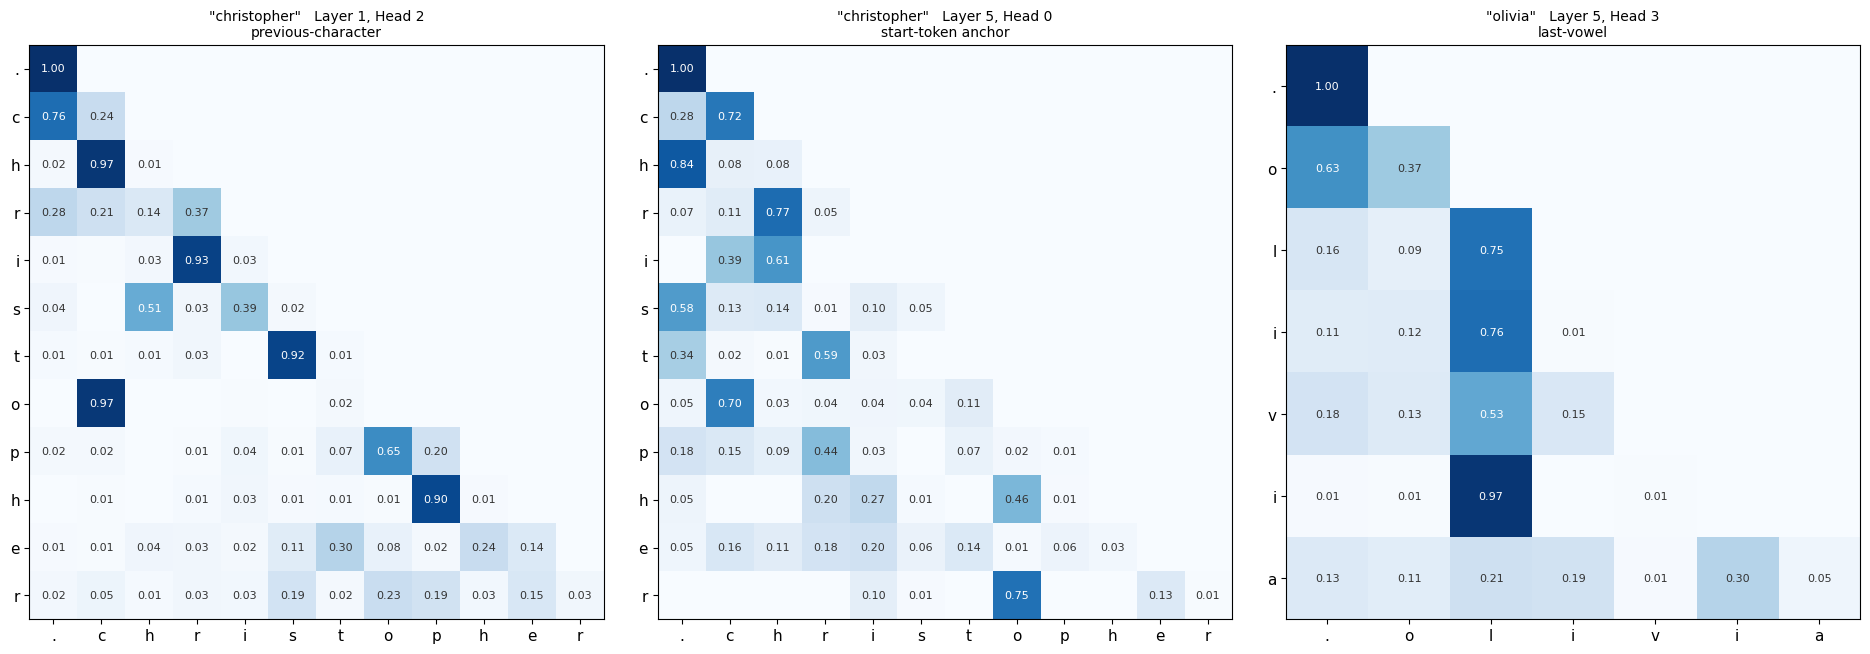

In [34]:
heroes = [('christopher', 1, 2, 'Layer 1, Head 2\nprevious-character'),
          ('christopher', 5, 0, 'Layer 5, Head 0\nstart-token anchor'),
          ('olivia',      5, 3, 'Layer 5, Head 3\nlast-vowel')]

fig, axes = plt.subplots(1, 3, figsize=(19, 6.2))
for ax, (nm, L, H, title) in zip(axes, heroes):
    maps, labels = attention_maps(nm)
    draw_head(ax, maps[L][H], labels, f'"{nm}"   {title}', annotate=True)
plt.tight_layout()
plt.savefig('outputs/plots/13_hero_heads.png', dpi=120)
plt.show()

### The verdict on the three predictions

**Previous-character head: held, and it is the cleanest thing in the model.** Layer 1, Head 2 is almost pure subdiagonal. In "christopher" the `h` sends 0.97 of its attention to the `c` before it, `i` sends 0.94 to its `r`, `t` sends 0.93 to its preceding character. The transformer rebuilt the bigram model from Part 2 inside its first layers, entirely on its own, because the previous character really is the single strongest cue for the next one. This is my favourite result in the notebook: the whole series comes full circle, with Part 2 living inside Part 6 as one attention head.

**Start-token anchor: held, with a twist I did not predict.** It is real, Layer 5, Head 0 sends 0.95 of `c`'s attention and 0.92 of `h`'s to the `.` start token, but it is a *deep-layer* feature, not something the early layers do, and it is strongest for the opening characters of a name and fades further in. So "bright first column" is right for the top rows and softens below them. Prediction correct, but the depth organisation above is what explains where it lives.

**Last-vowel head: this is the one that did not hold cleanly, and it is the most interesting.** I predicted vowel-column stripes, and at first glance the early layers seemed to show them. They do not. What looked like a vowel head in Layers 0 and 1 was just the previous-character head: names alternate consonants and vowels, so the character before a consonant is very often a vowel, and a pure "look one step back" head therefore *lands on* vowels without having any concept of a vowel. The confound is total in the early layers. Only one head in the entire model, Layer 5, Head 3, does something that is genuinely vowel-seeking rather than position-seeking: in "olivia" the consonant `l` reaches back 0.49 to the `o`, and `v` reaches 0.95 to the `i`, skipping over position to find the vowel. The lesson is one I will not forget: you cannot name a head's job from one heatmap. A head that tracks position and a head that tracks content look identical whenever position and content are correlated, and you only tell them apart by finding a case where they disagree.

## Section 14: where this goes next

The whole series has been about one quantity: the length of the path a signal has to travel from an earlier character to the prediction that depends on it. The bigram had no path at all beyond one step. The MLP gave every character in its window an O(1) path to the output, but the window was frozen at three, so anything older than three characters had no path whatsoever. WaveNet reached the entire context, but through its binary tree, so a character `T` steps back arrives over O(log T) hops, each one a lossy fusion. Attention is the endpoint of this progression: every position has a direct, O(1) path to every earlier position, chosen from content and recomputed for every sequence. That is the structural reason it wins. But it is also exactly why the win here is only 0.10 nats. On names averaging six characters, log T is barely two hops and the fixed window is only a little too short, so the three architectures are competing over a gap that the data itself keeps small. The advantage of an O(1) path to anywhere only becomes decisive when "anywhere" is hundreds of tokens away, which is a property of the corpus, not of the model.

That is the second thing worth stating plainly: nothing about the architecture in this notebook is specific to names. The `Head`, the `MultiHeadAttention`, the `Block`, the Pre-LN residual stream, the token and position embeddings, the training loop, all of it is the same code that trains a GPT. Scaling from this to a model that writes Shakespeare, or to one trained on the whole internet, changes the dataset, the tokenizer (characters give way to subword tokens), and the sizes (`block_size`, `n_embd`, `n_layer` all grow by one or two orders of magnitude). It does not change the mechanism. The 303k-parameter model here and a 175-billion-parameter GPT are the same diagram from Section 9, stacked deeper and fed more.

If you want to see where this goes next: my Shakespeare GPT repo takes this exact architecture and scales it up on a real text corpus with the update-ratio diagnostics from Section 11 driven further, and my tensorgrad repo rebuilds from scratch the autograd engine that every backward pass in this series quietly relied on. Same ladder, more rungs.